<a href="https://www.kaggle.com/code/omborse771924/superconduct-eda?scriptVersionId=335994430" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/felixfuhrmann02/superconduct/superconduct_train.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/felixfuhrmann02/superconduct/superconduct_train.csv')

In [3]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
df.tail()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
21258,4,106.957877,53.095769,82.515384,43.135565,1.177145,1.254119,146.88130,15.504479,65.764081,...,3.555556,3.223710,3.519911,1.377820,0.913658,1,2.168889,0.433013,0.496904,2.44
21259,5,92.266740,49.021367,64.812662,32.867748,1.323287,1.571630,188.38390,7.353333,69.232655,...,2.047619,2.168944,2.038991,1.594167,1.337246,1,0.904762,0.400000,0.212959,122.10
21260,2,99.663190,95.609104,99.433882,95.464320,0.690847,0.530198,13.51362,53.041104,6.756810,...,4.800000,4.472136,4.781762,0.686962,0.450561,1,3.200000,0.500000,0.400000,1.98
21261,2,99.663190,97.095602,99.433882,96.901083,0.690847,0.640883,13.51362,31.115202,6.756810,...,4.690000,4.472136,4.665819,0.686962,0.577601,1,2.210000,0.500000,0.462493,1.84
21262,3,87.468333,86.858500,82.555758,80.458722,1.041270,0.895229,71.75500,43.144000,29.905282,...,4.500000,4.762203,4.242641,1.054920,0.970116,3,1.800000,1.414214,1.500000,12.80


In [5]:
df.info

<bound method DataFrame.info of        number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                       4         88.944468             57.862692   
1                       5         92.729214             58.518416   
2                       4         88.944468             57.885242   
3                       4         88.944468             57.873967   
4                       4         88.944468             57.840143   
...                   ...               ...                   ...   
21258                   4        106.957877             53.095769   
21259                   5         92.266740             49.021367   
21260                   2         99.663190             95.609104   
21261                   2         99.663190             97.095602   
21262                   3         87.468333             86.858500   

       gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0              66.361592              36.116612             1.18179

In [6]:
df.isnull

<bound method DataFrame.isnull of        number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                       4         88.944468             57.862692   
1                       5         92.729214             58.518416   
2                       4         88.944468             57.885242   
3                       4         88.944468             57.873967   
4                       4         88.944468             57.840143   
...                   ...               ...                   ...   
21258                   4        106.957877             53.095769   
21259                   5         92.266740             49.021367   
21260                   2         99.663190             95.609104   
21261                   2         99.663190             97.095602   
21262                   3         87.468333             86.858500   

       gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0              66.361592              36.116612             1.181

In [7]:
df.isnull().sum()

number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64

In [8]:
df.describe(
    
)

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


In [9]:
df.duplicated().sum()

np.int64(66)

In [10]:
df.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

## EDA

In [11]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

# Load Dataset
# df = pd.read_csv("your_dataset.csv")

print(df.head())
print(df.shape)

   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.181795   

   wtd_entropy_atomic_mass  range_atomic_mass  wtd_range_atomic_mass  \
0                 1.062396          122.90607              31.794921   
1                 1.057755          122.90607           

In [12]:
print("="*60)
print(df.info())
print("="*60)

print(df.describe().T)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:",df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

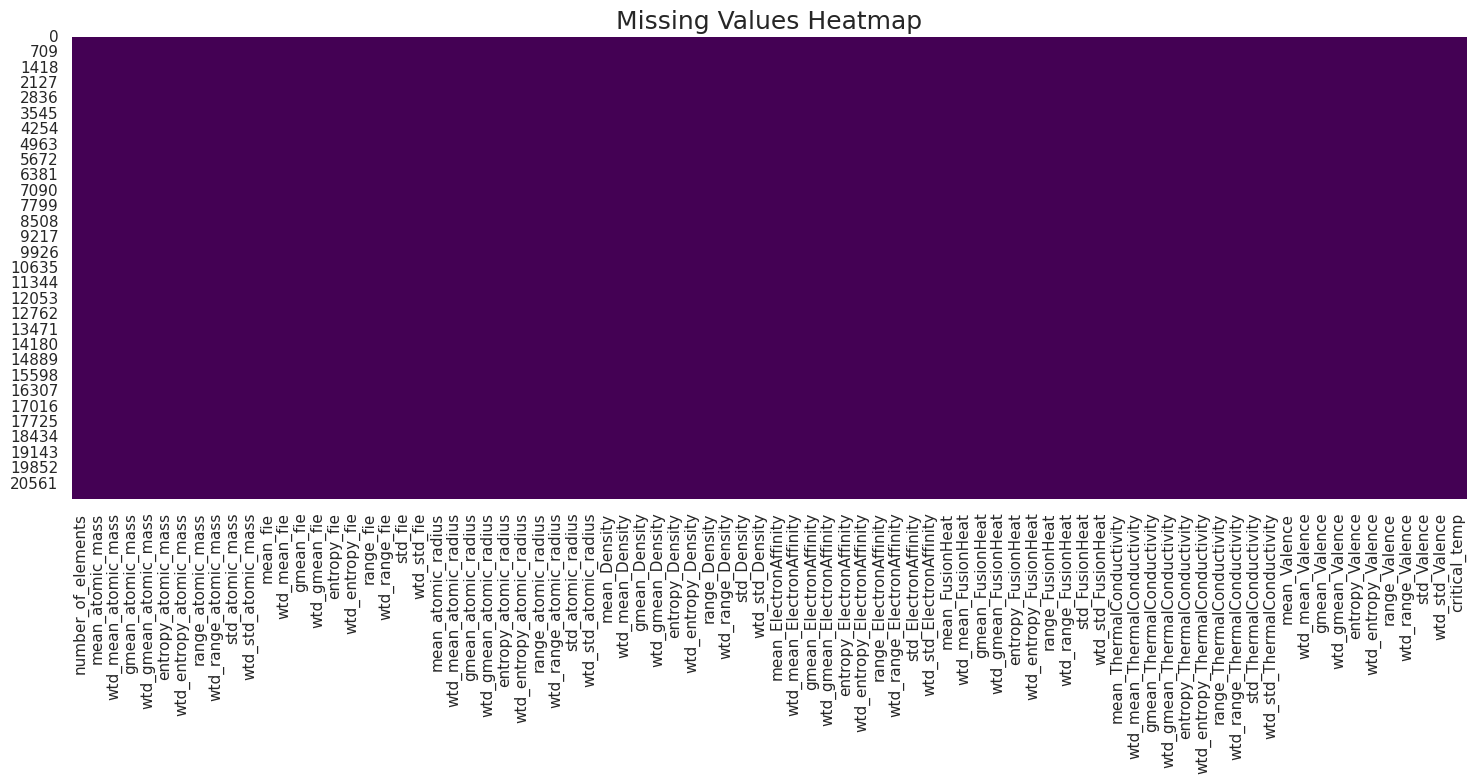

In [13]:
plt.figure(figsize=(18,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap",fontsize=18)
plt.show()

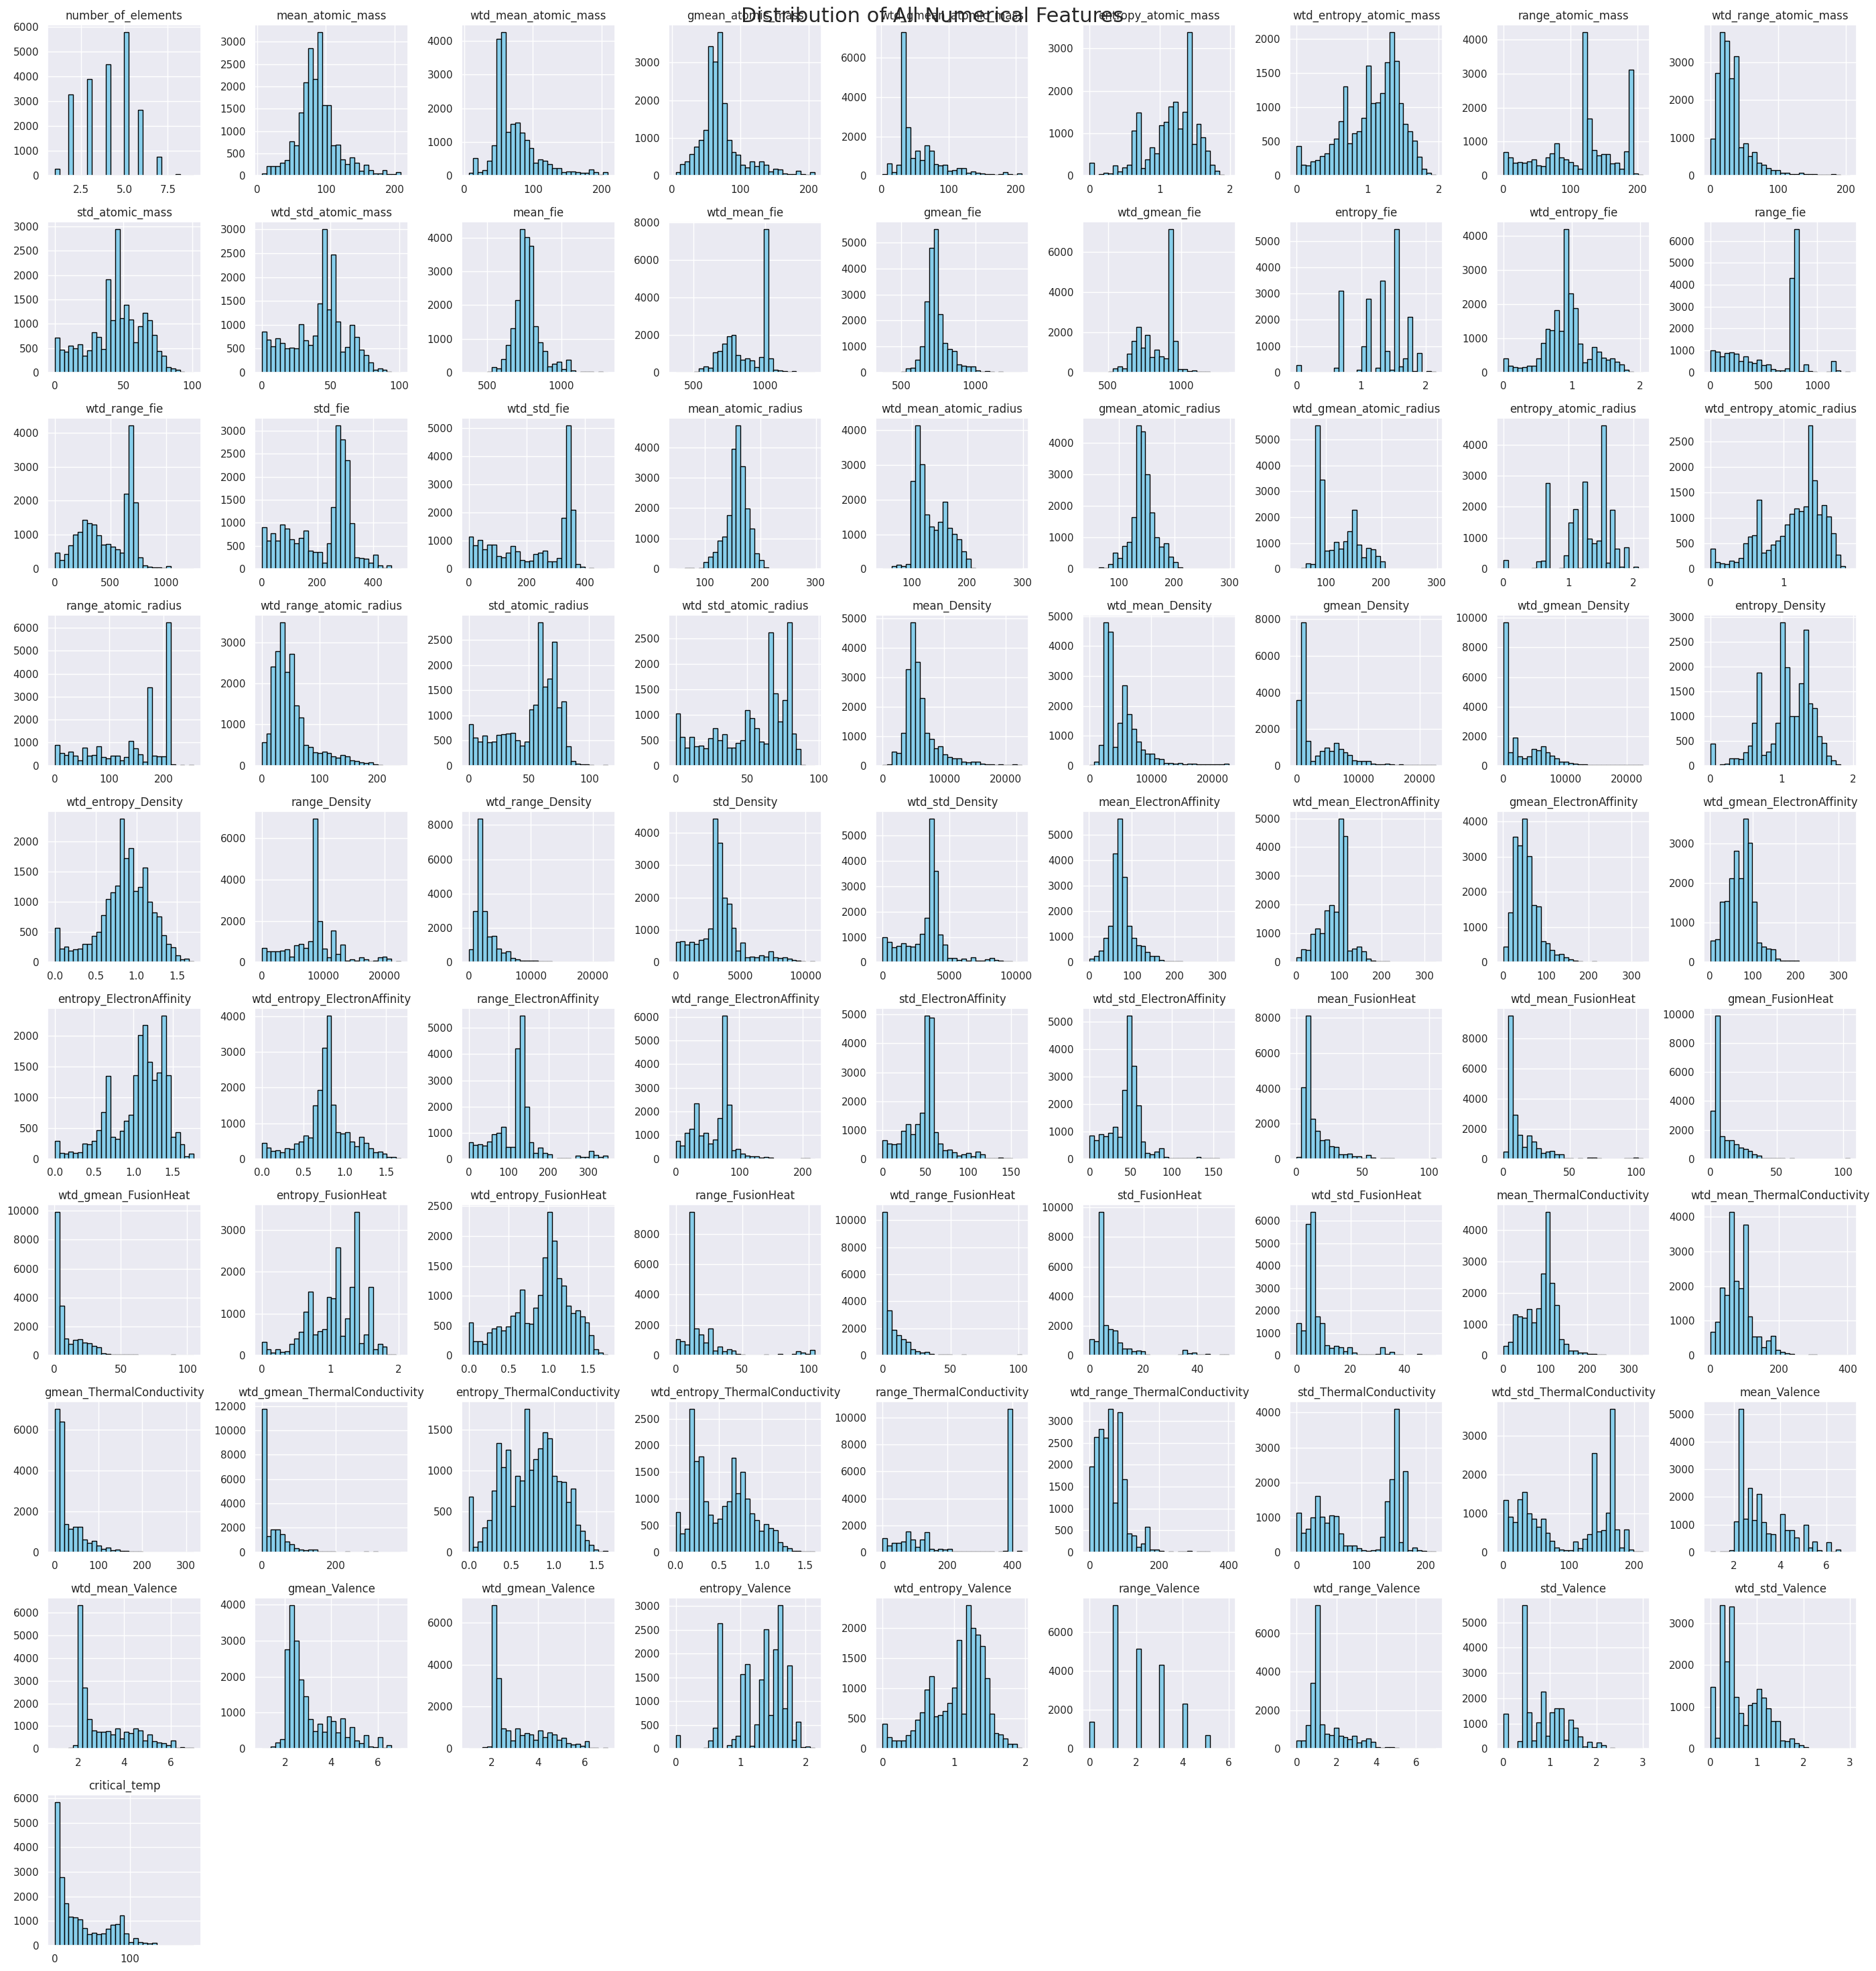

In [14]:
df.hist(
    figsize=(28,30),
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Distribution of All Numerical Features",fontsize=22)
plt.tight_layout()
plt.show()

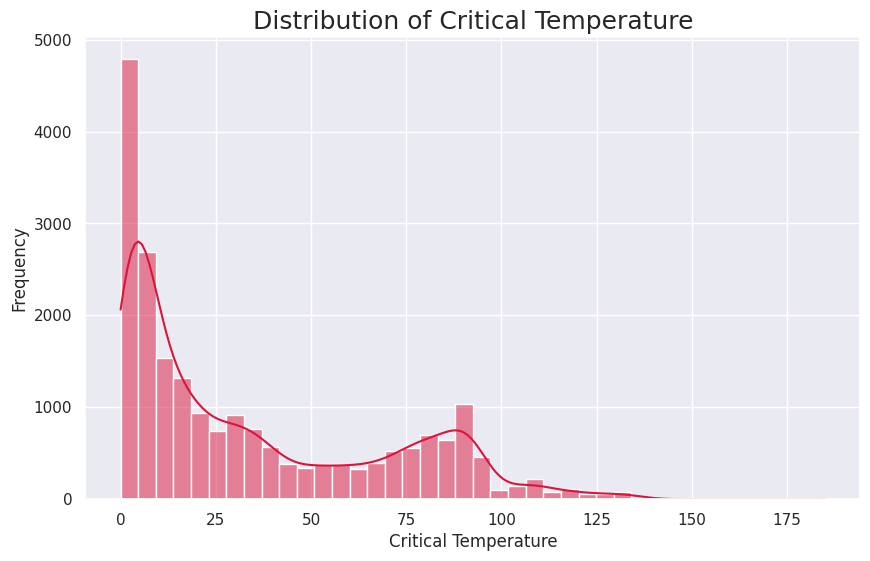

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["critical_temp"],
    bins=40,
    kde=True,
    color="crimson"
)

plt.title("Distribution of Critical Temperature",fontsize=18)
plt.xlabel("Critical Temperature")
plt.ylabel("Frequency")
plt.show()

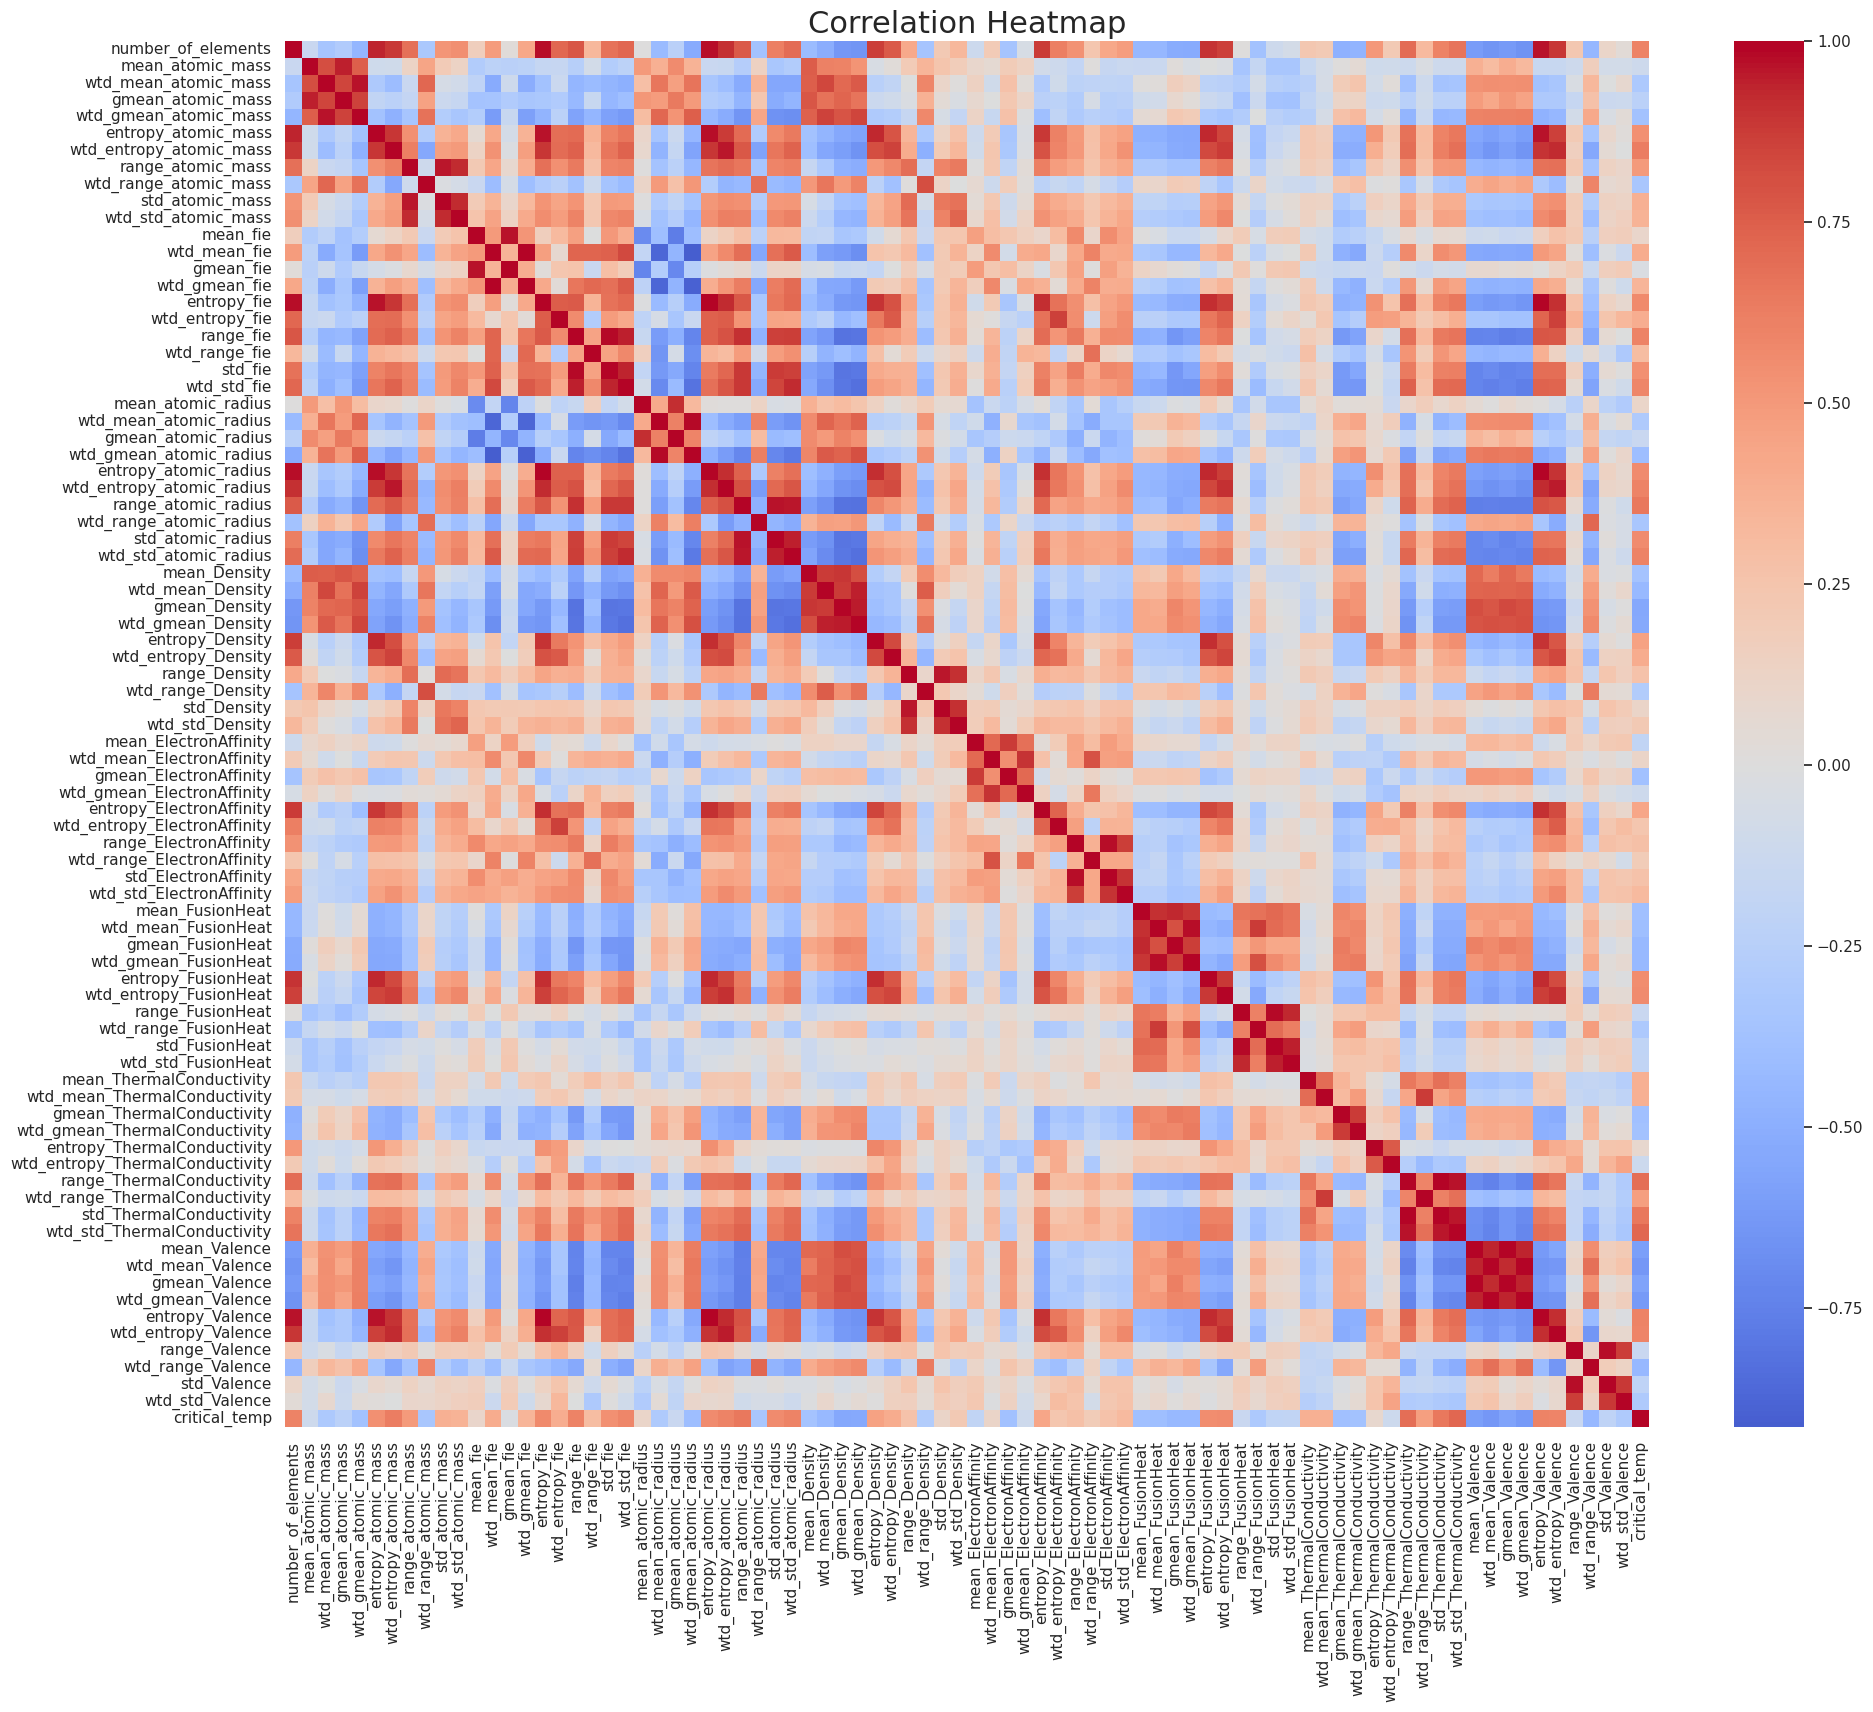

In [16]:
plt.figure(figsize=(22,18))

corr=df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap",fontsize=22)

plt.show()

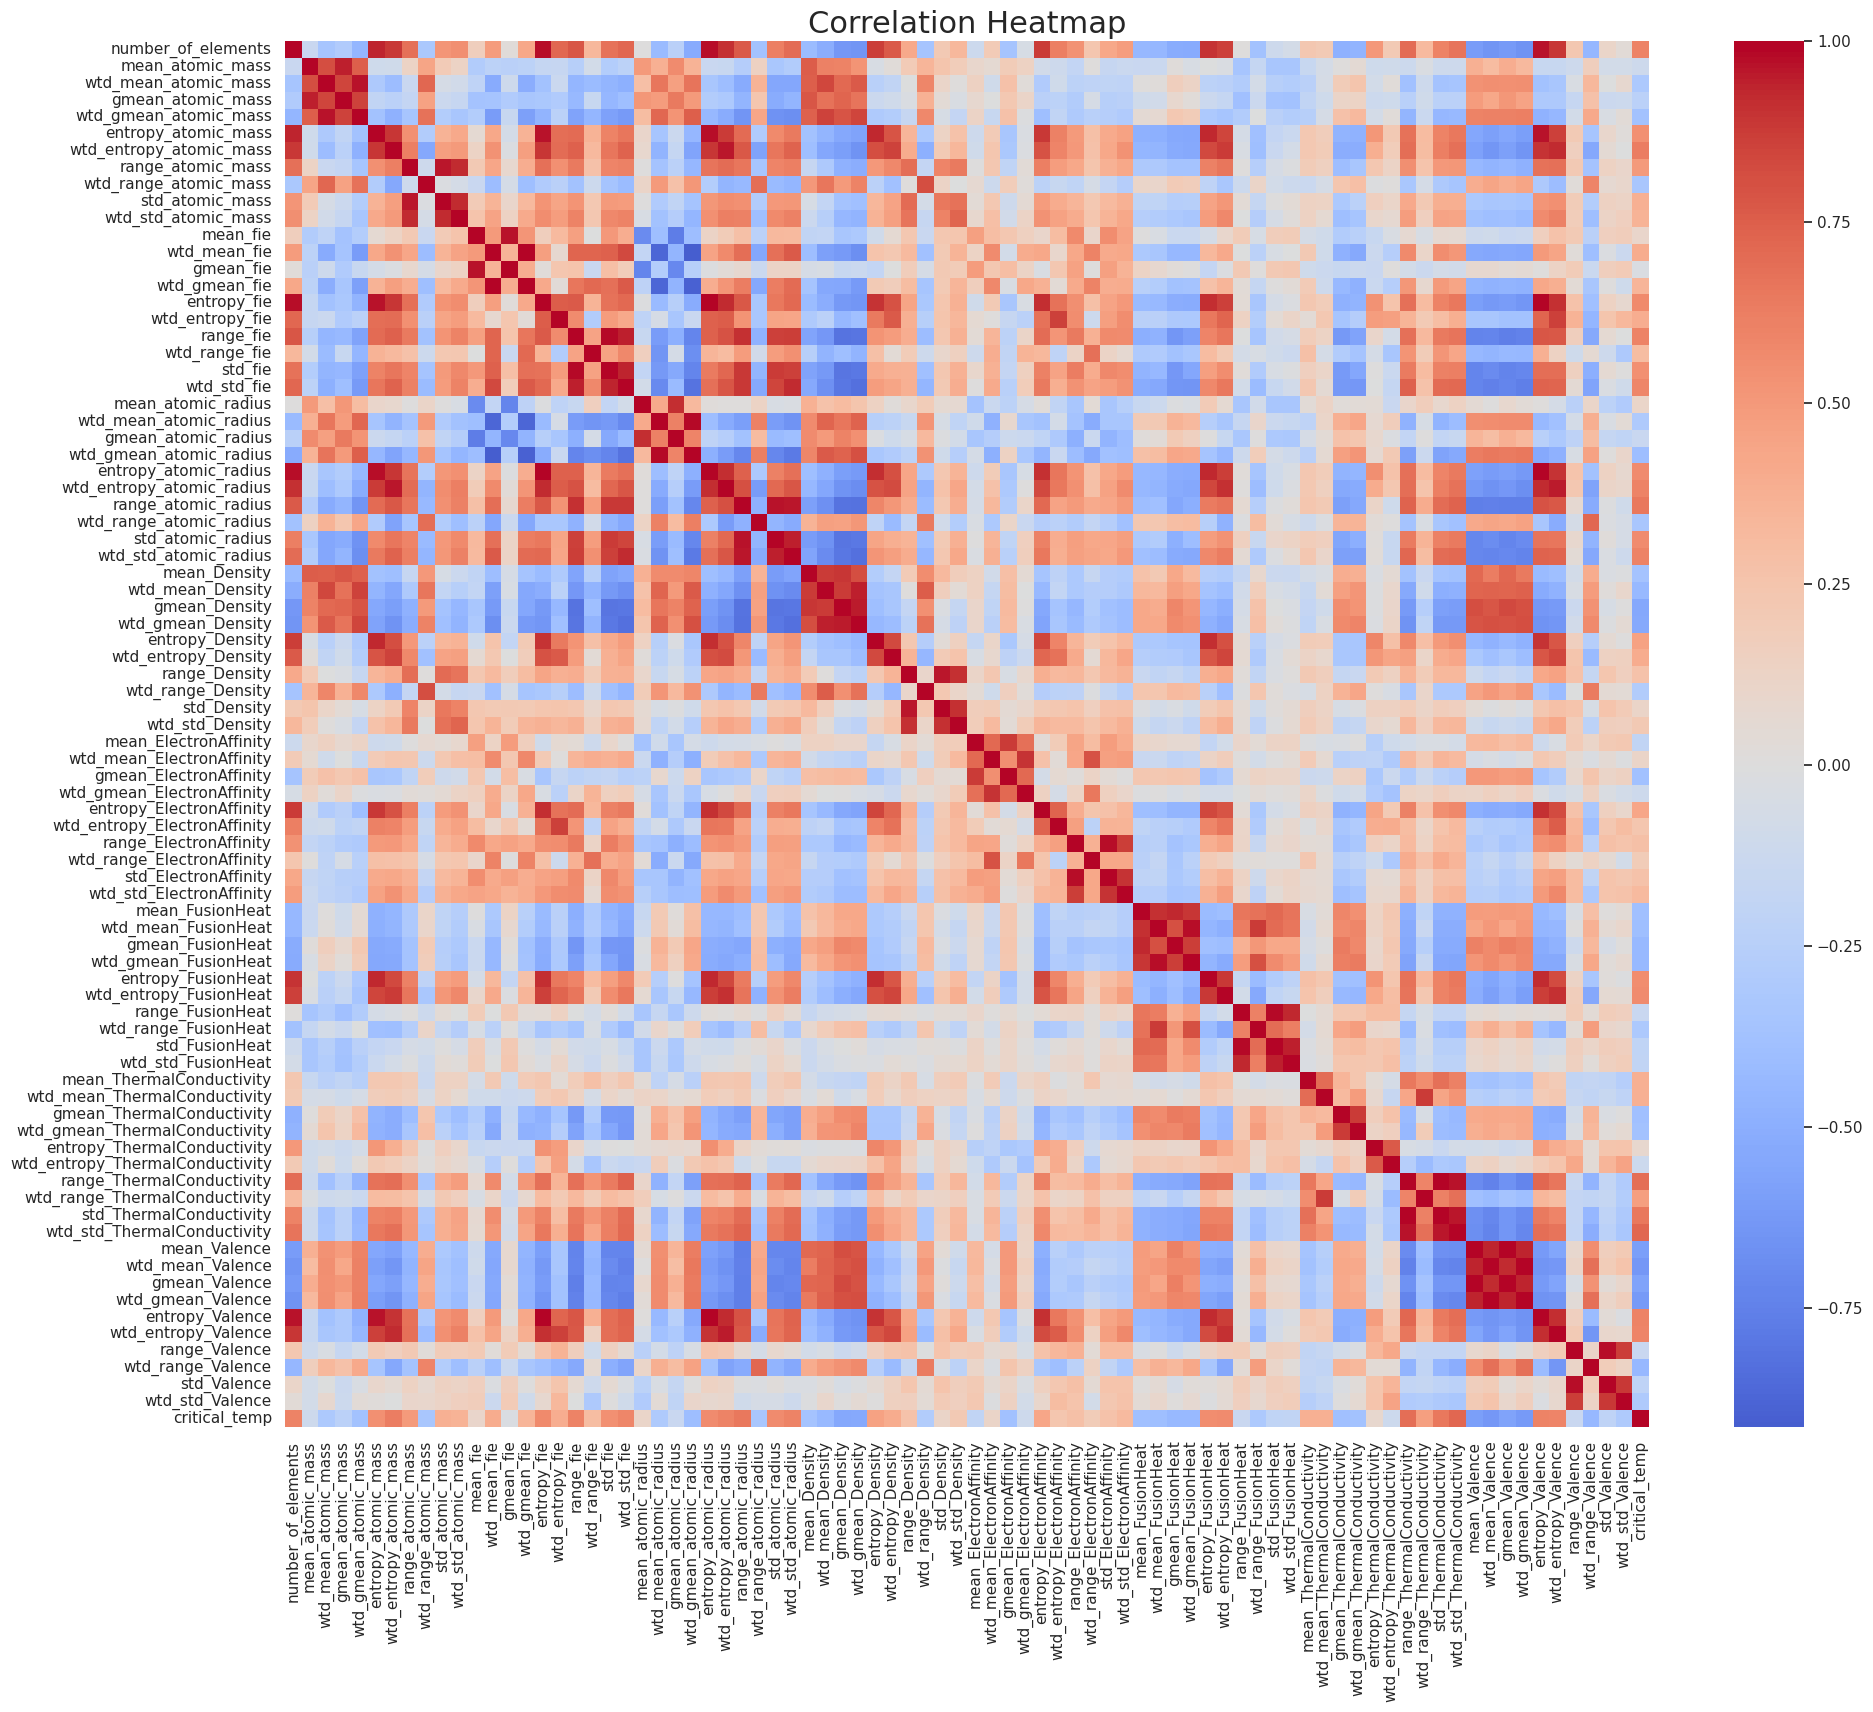

In [17]:
plt.figure(figsize=(22,18))

corr=df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap",fontsize=22)

plt.show()

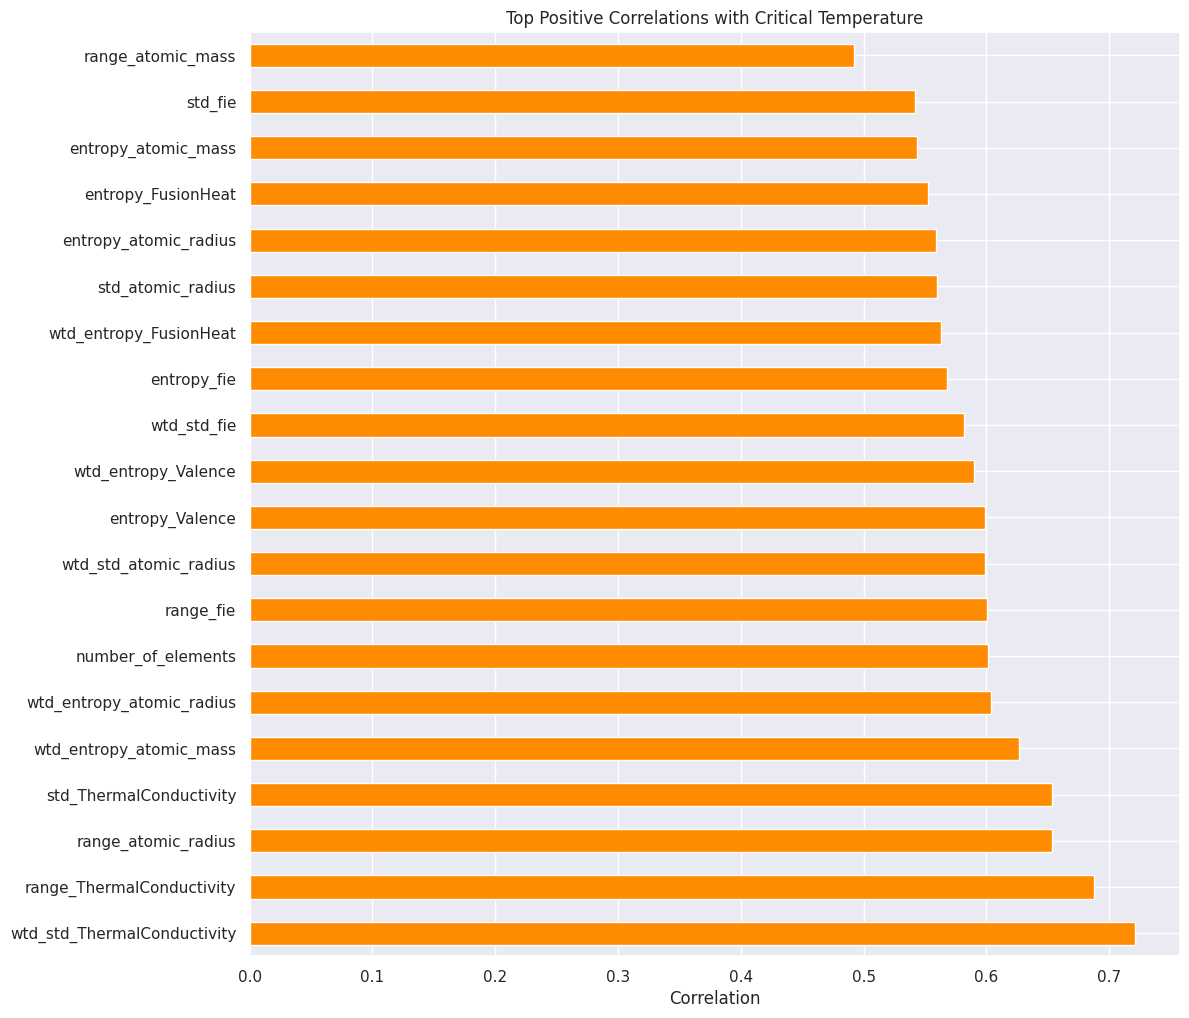

In [18]:
corr_target=df.corr(numeric_only=True)["critical_temp"]\
                .drop("critical_temp")\
                .sort_values(ascending=False)

plt.figure(figsize=(12,12))

corr_target.head(20).plot(
    kind="barh",
    color="darkorange"
)

plt.title("Top Positive Correlations with Critical Temperature")
plt.xlabel("Correlation")
plt.show()

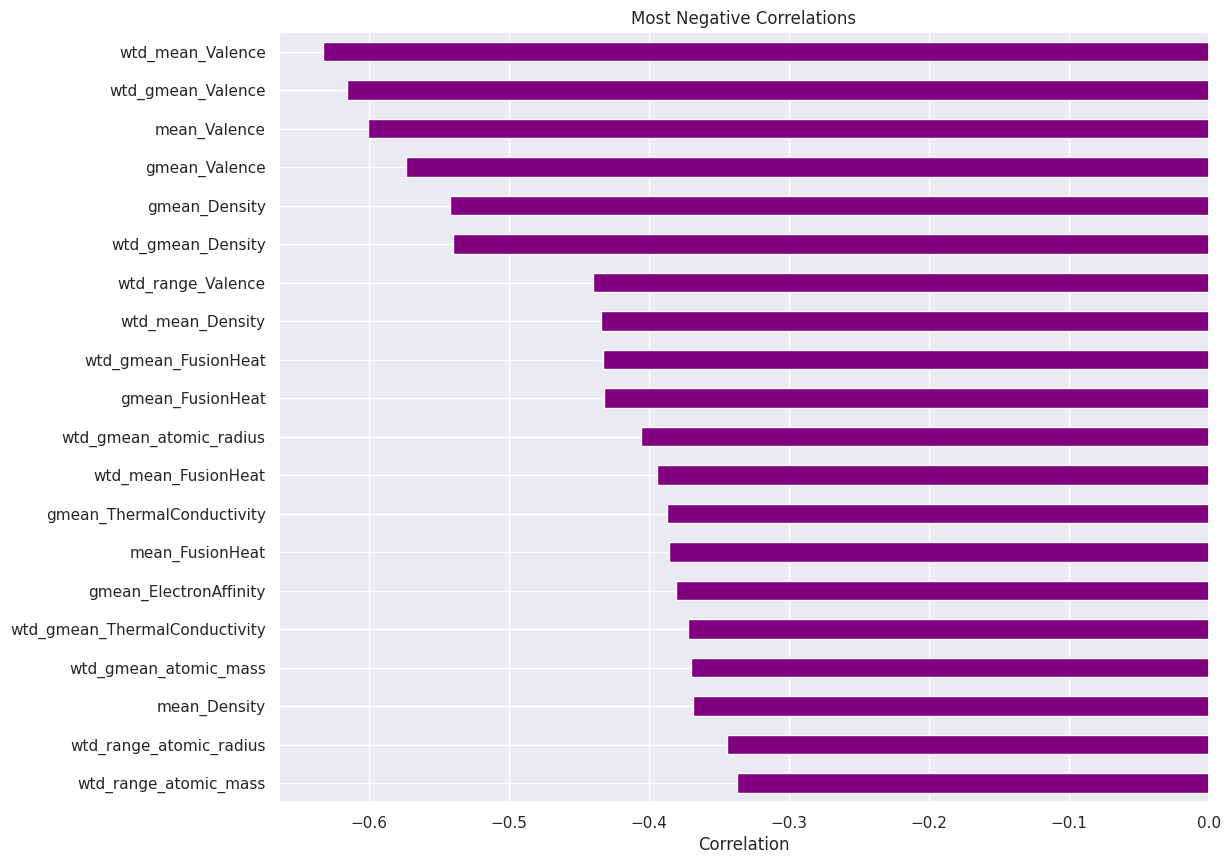

In [19]:
plt.figure(figsize=(12,10))

corr_target.tail(20).plot(
    kind="barh",
    color="purple"
)

plt.title("Most Negative Correlations")
plt.xlabel("Correlation")
plt.show()

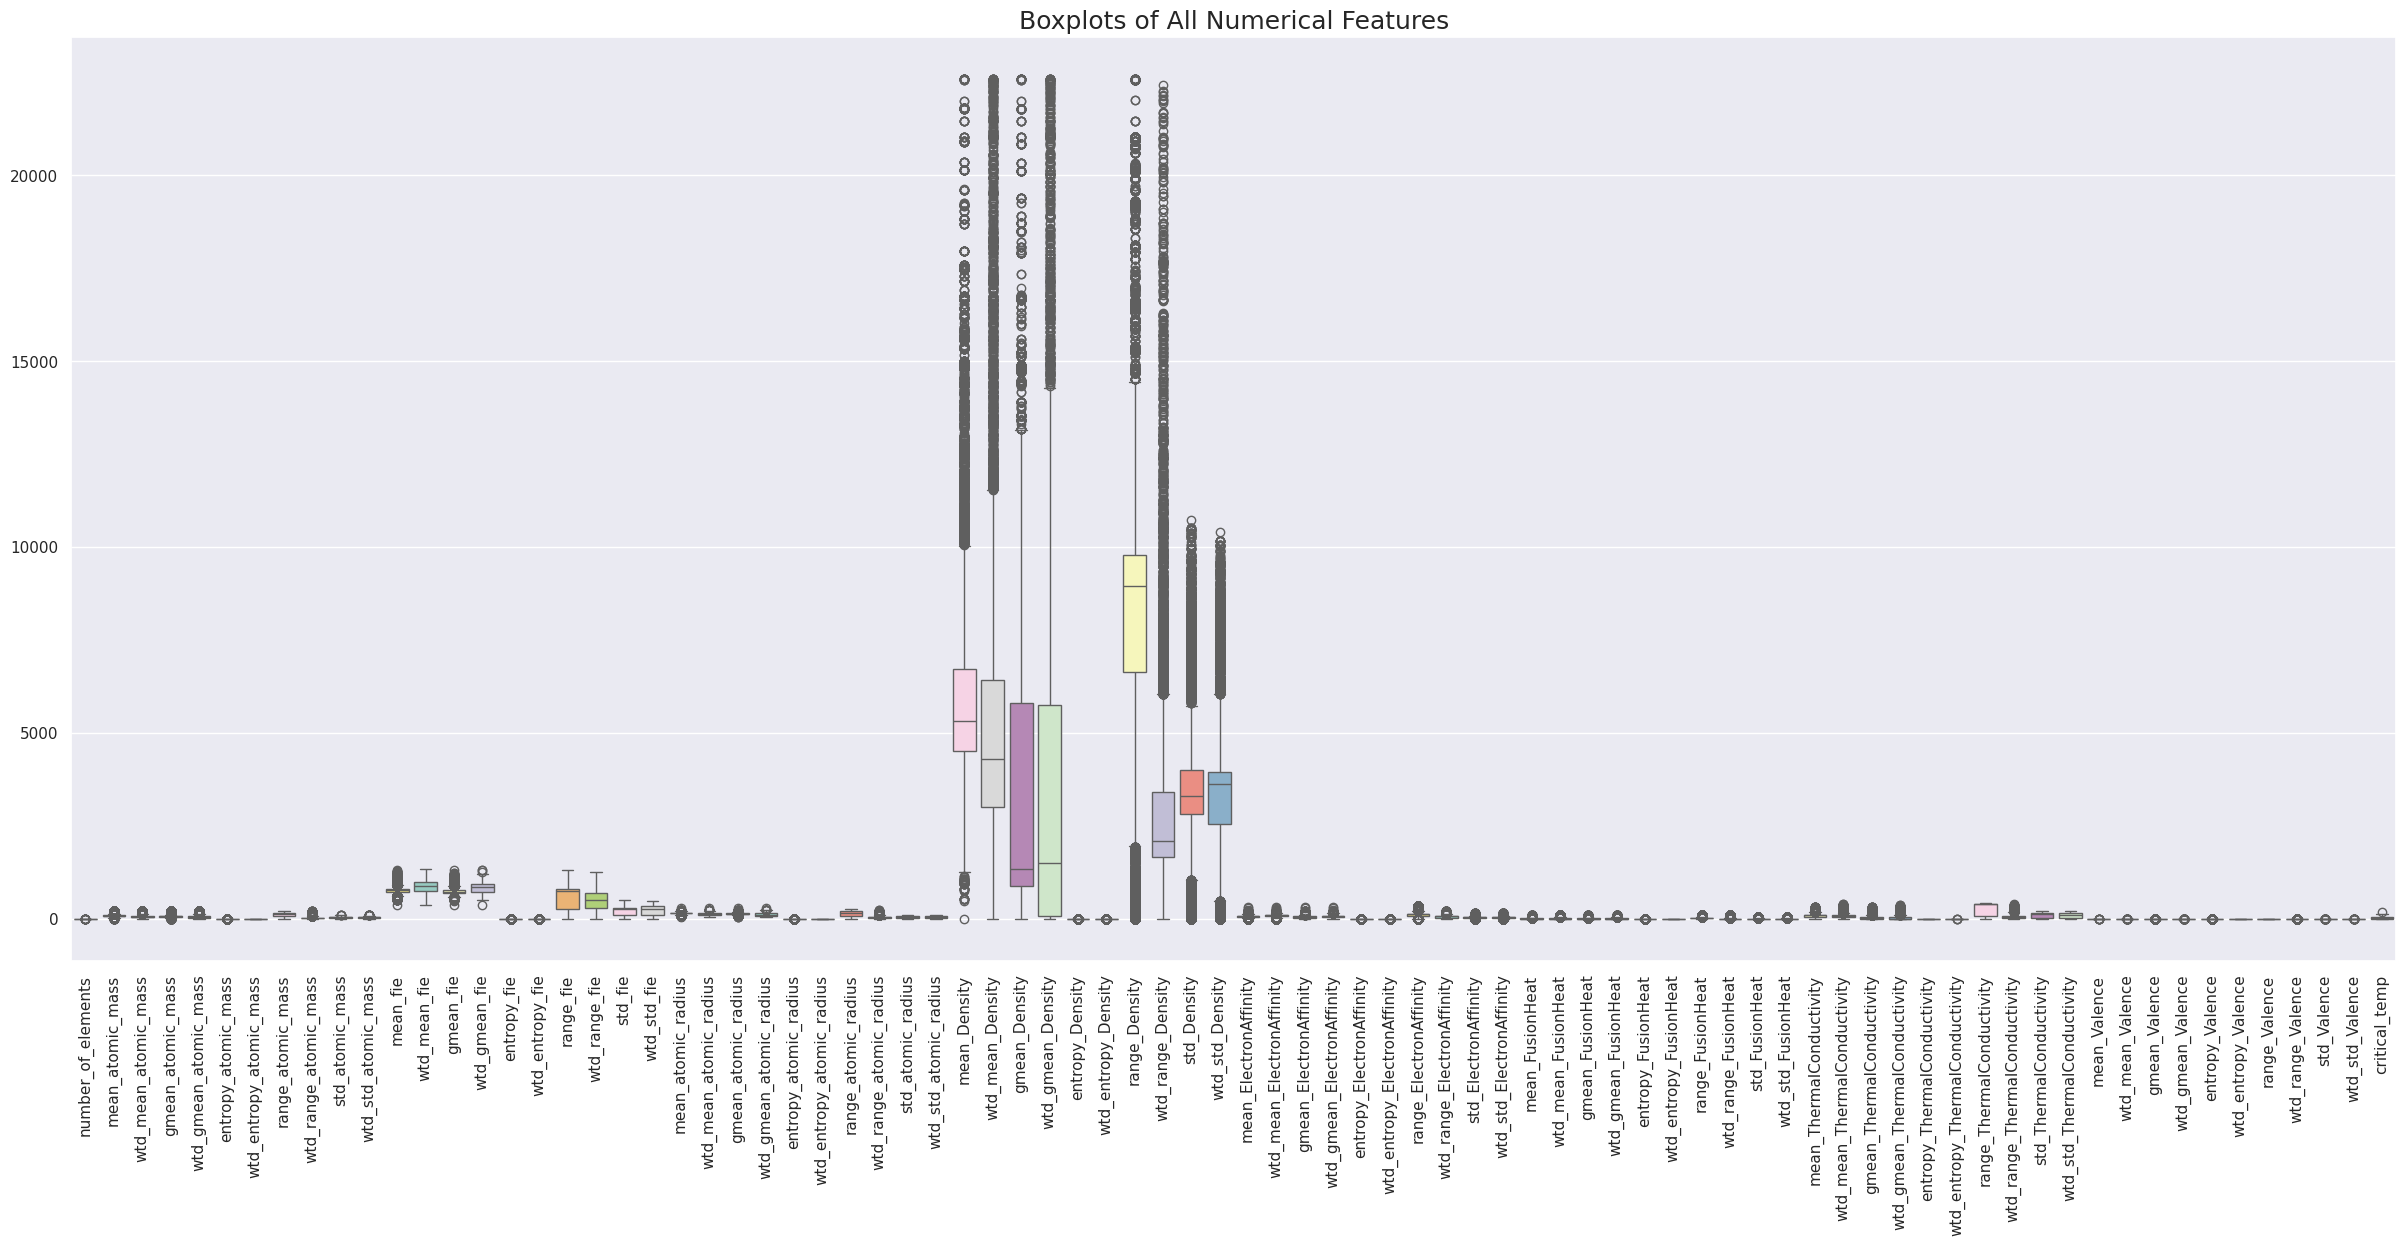

In [20]:
plt.figure(figsize=(30,12))

sns.boxplot(
    data=df,
    palette="Set3"
)

plt.xticks(rotation=90)

plt.title("Boxplots of All Numerical Features",fontsize=18)

plt.show()

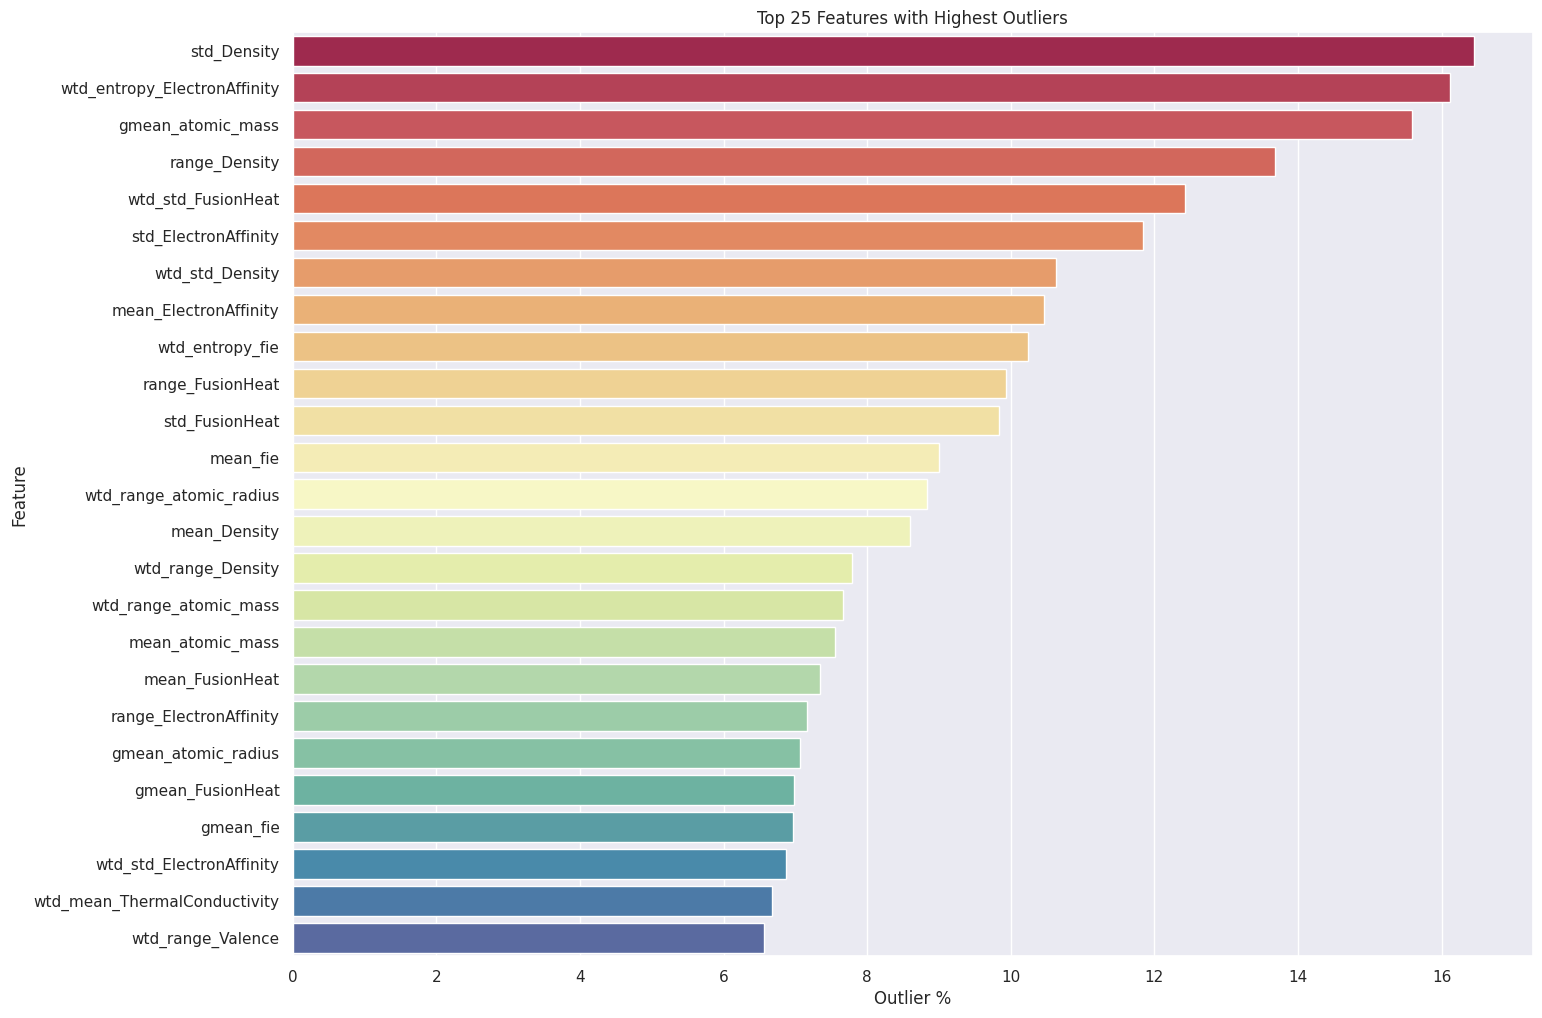

In [21]:
outlier_percent={}

for col in df.columns:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    outliers=((df[col]<lower)|(df[col]>upper)).sum()

    outlier_percent[col]=100*outliers/len(df)

outliers=pd.DataFrame(
    outlier_percent.items(),
    columns=["Feature","Outlier %"]
)

outliers=outliers.sort_values(
    by="Outlier %",
    ascending=False
)

plt.figure(figsize=(16,12))

sns.barplot(
    data=outliers.head(25),
    x="Outlier %",
    y="Feature",
    hue="Feature",
    dodge=False,
    palette="Spectral",
    legend=False
)

plt.title("Top 25 Features with Highest Outliers")

plt.show()

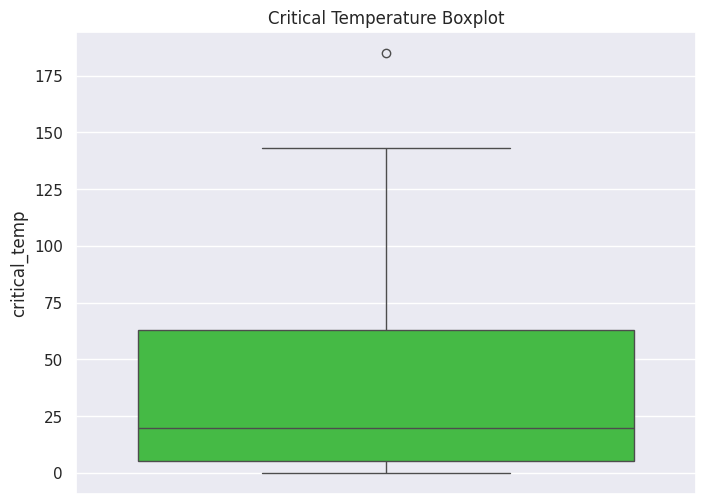

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["critical_temp"],
    color="limegreen"
)

plt.title("Critical Temperature Boxplot")

plt.show()

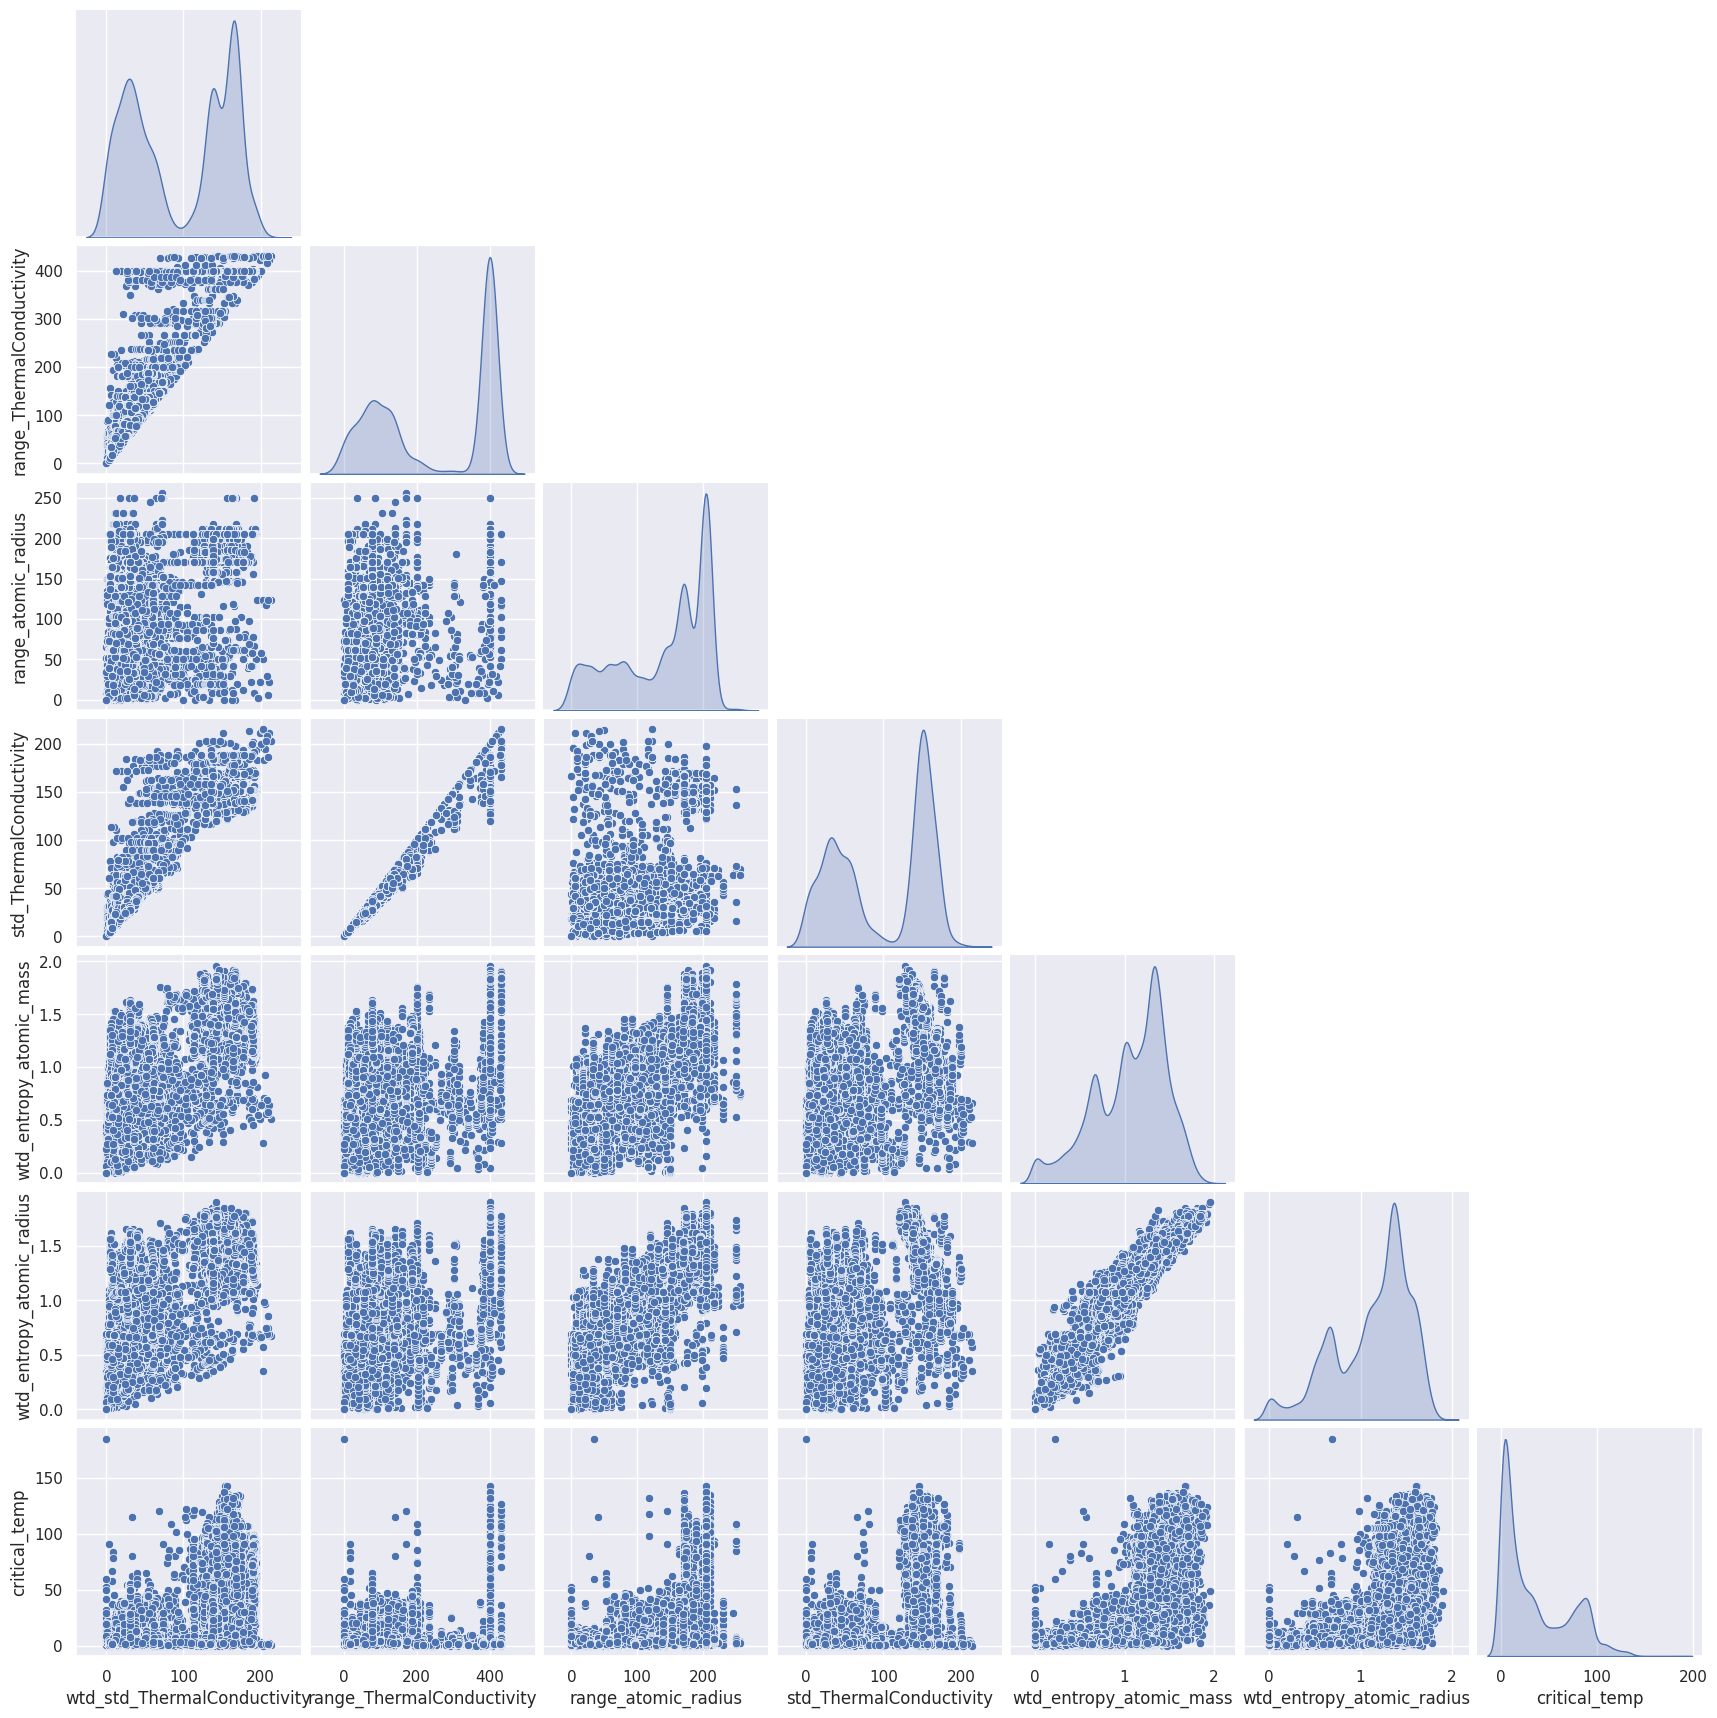

In [23]:
top_features = corr_target.head(6).index.tolist()

sns.pairplot(
    df[top_features + ["critical_temp"]],
    corner=True,
    diag_kind="kde"
)

plt.show()

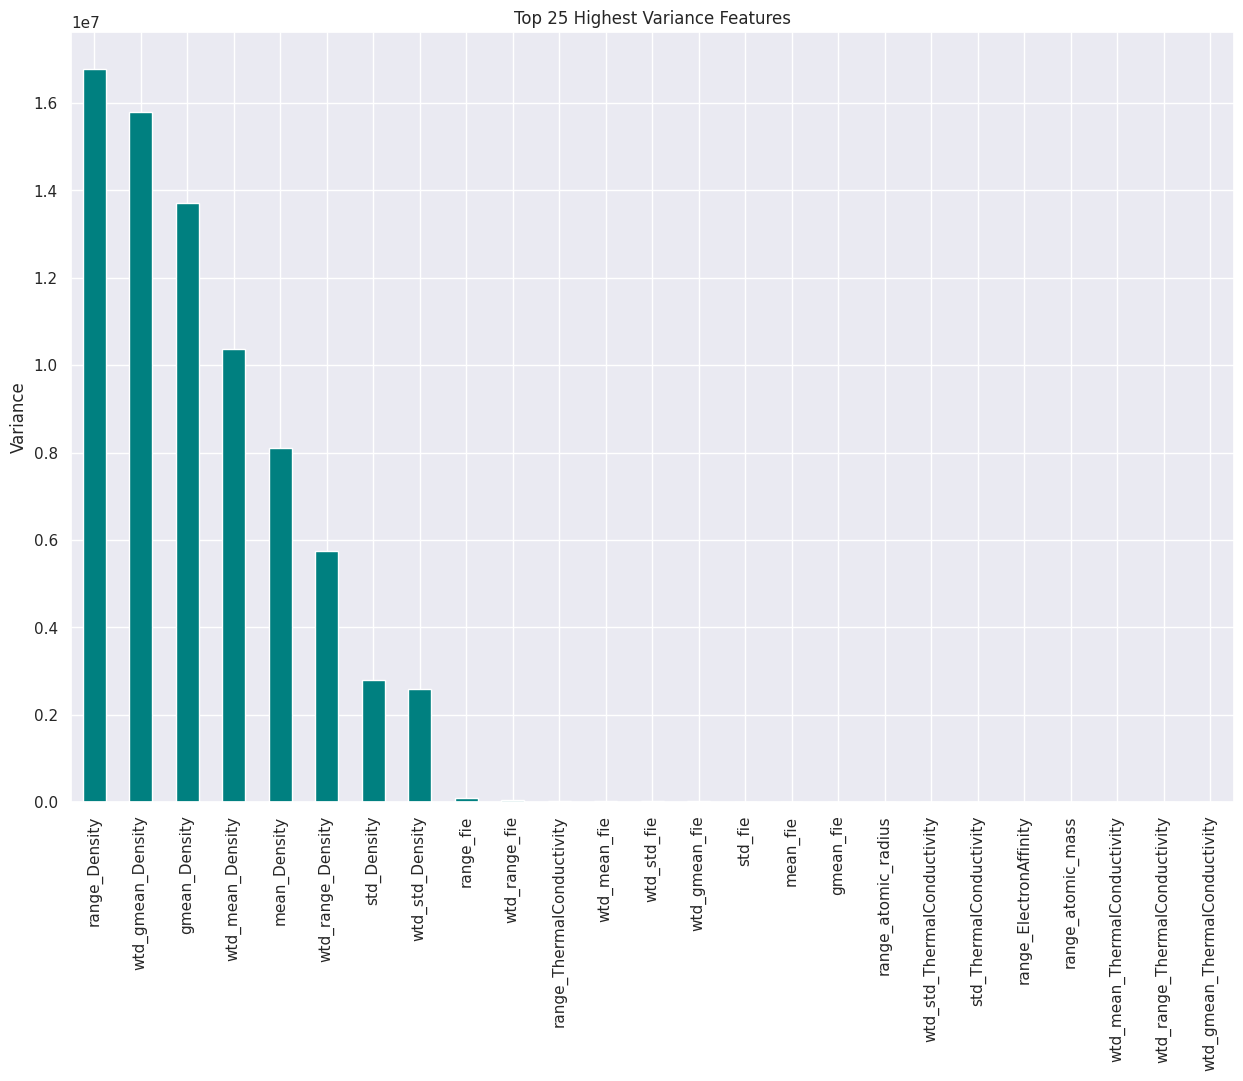

In [24]:
variance=df.var().sort_values(ascending=False)

plt.figure(figsize=(15,10))

variance.head(25).plot(
    kind="bar",
    color="teal"
)

plt.title("Top 25 Highest Variance Features")

plt.ylabel("Variance")

plt.show()

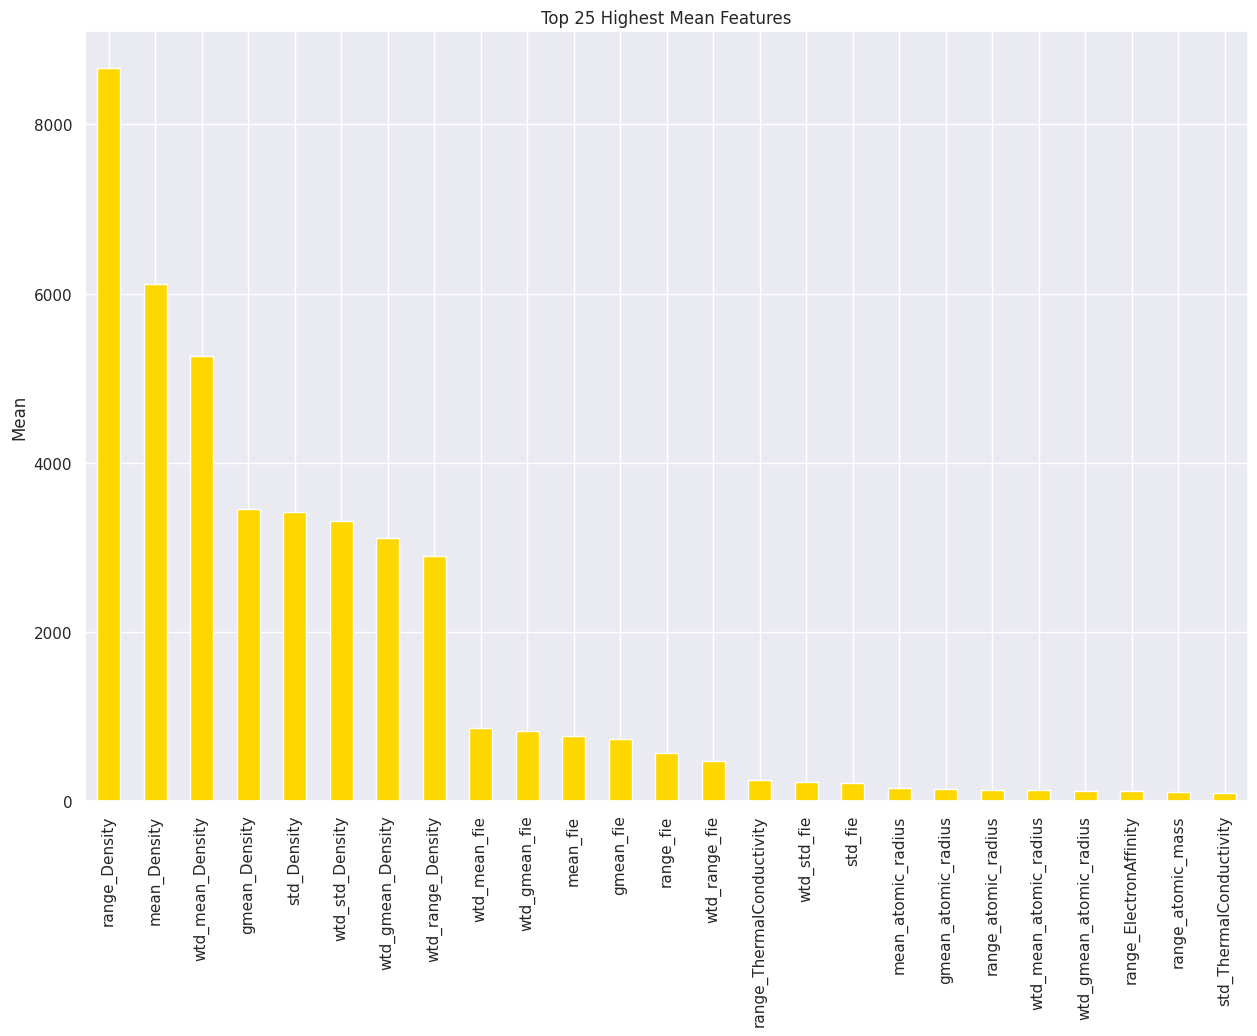

In [25]:
means=df.mean().sort_values(ascending=False)

plt.figure(figsize=(15,10))

means.head(25).plot(
    kind="bar",
    color="gold"
)

plt.title("Top 25 Highest Mean Features")

plt.ylabel("Mean")

plt.show()

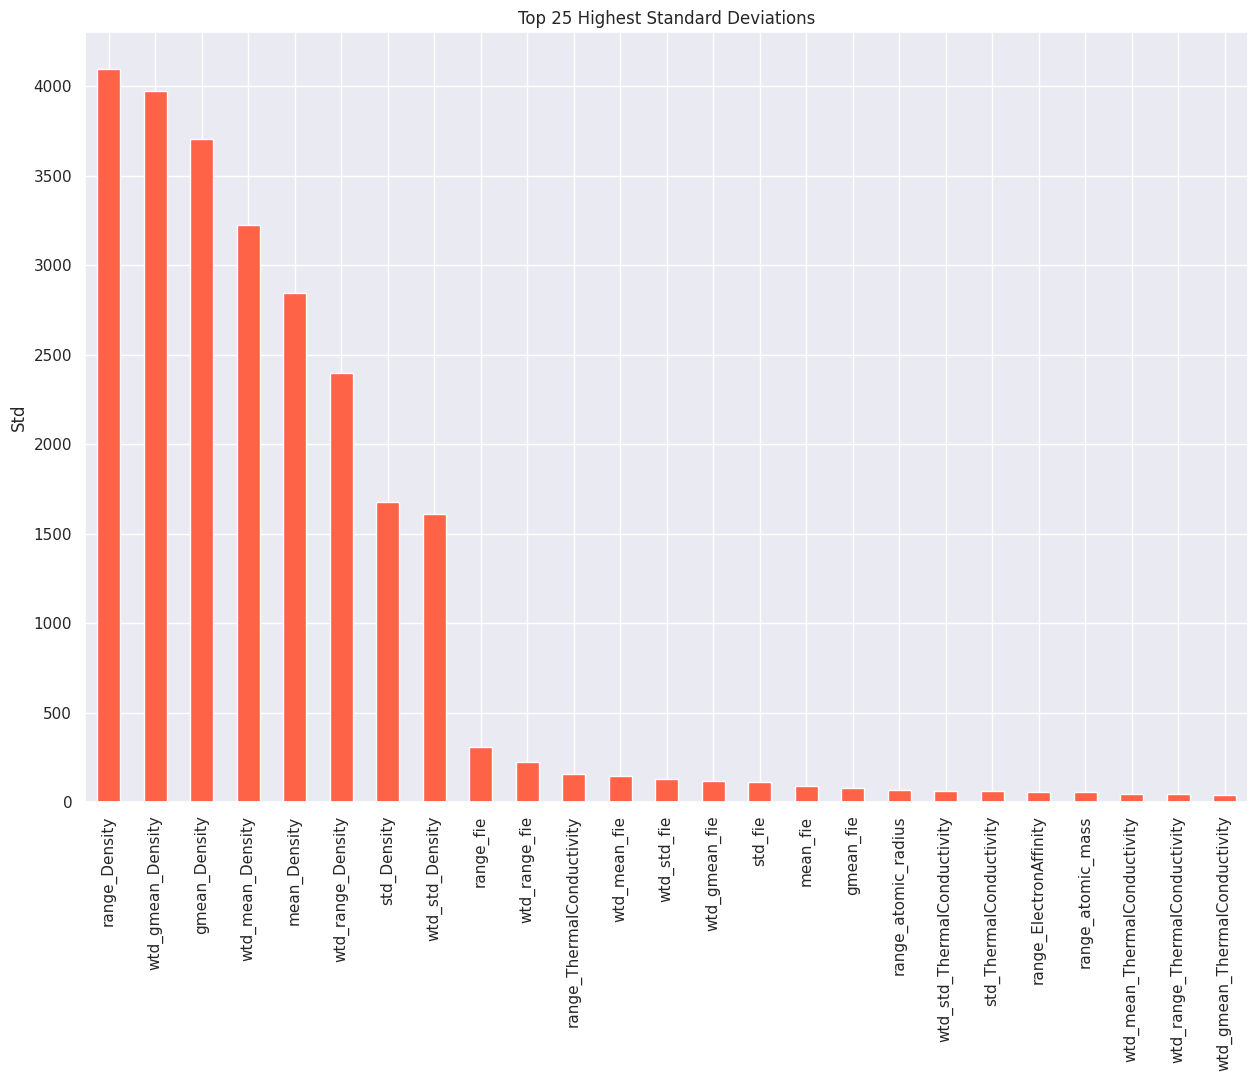

In [26]:
std=df.std().sort_values(ascending=False)

plt.figure(figsize=(15,10))

std.head(25).plot(
    kind="bar",
    color="tomato"
)

plt.title("Top 25 Highest Standard Deviations")

plt.ylabel("Std")

plt.show()

## Features Engineering

   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.181795   

   wtd_entropy_atomic_mass  range_atomic_mass  wtd_range_atomic_mass  \
0                 1.062396          122.90607              31.794921   
1                 1.057755          122.90607           

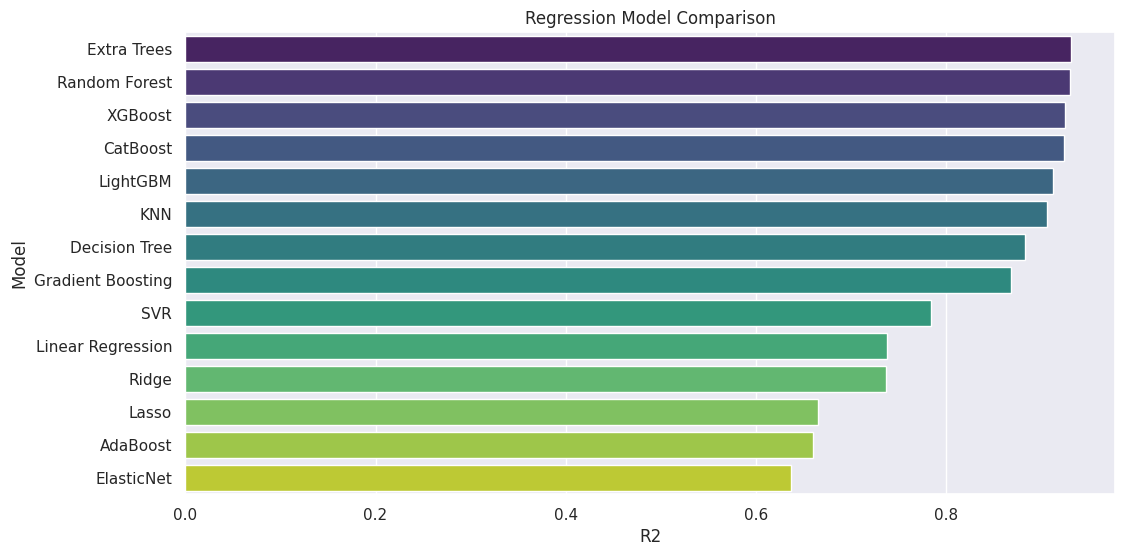


Best Model : Extra Trees


In [27]:
# ============================================================
# SUPERCONDUCTOR DATASET - REGRESSION PIPELINE (PART 1)
# ============================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    explained_variance_score
)

# ==========================
# Regression Algorithms
# ==========================

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

# Optional Models

try:
    from xgboost import XGBRegressor
    xgb_available=True
except:
    xgb_available=False

try:
    from lightgbm import LGBMRegressor
    lgbm_available=True
except:
    lgbm_available=False

try:
    from catboost import CatBoostRegressor
    cat_available=True
except:
    cat_available=False


# =====================================================
# LOAD DATASET
# =====================================================

# df = pd.read_csv("superconduct.csv")

print(df.head())

print(df.shape)

print(df.info())

# =====================================================
# TARGET
# =====================================================

target="critical_temp"

X=df.drop(columns=[target])

y=df[target]

print("\nFeature Shape :",X.shape)

print("Target Shape :",y.shape)


# =====================================================
# CATEGORICAL & NUMERICAL COLUMNS
# =====================================================

categorical_columns=X.select_dtypes(include=["object"]).columns.tolist()

numerical_columns=X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nNumerical Columns :",len(numerical_columns))

print("Categorical Columns :",len(categorical_columns))


# =====================================================
# PREPROCESSOR
# =====================================================

numeric_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="median")),

        ("scaler",StandardScaler())

    ]

)

categorical_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="most_frequent")),

        ("encoder",OneHotEncoder(handle_unknown="ignore"))

    ]

)

preprocessor=ColumnTransformer(

    transformers=[

        ("num",numeric_transformer,numerical_columns),

        ("cat",categorical_transformer,categorical_columns)

    ]

)


# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("\nTrain Shape :",X_train.shape)

print("Test Shape :",X_test.shape)


# =====================================================
# MODELS
# =====================================================

models={

    "Linear Regression":LinearRegression(),

    "Ridge":Ridge(),

    "Lasso":Lasso(),

    "ElasticNet":ElasticNet(),

    "Decision Tree":DecisionTreeRegressor(random_state=42),

    "Random Forest":RandomForestRegressor(

        n_estimators=200,
        random_state=42,
        n_jobs=-1

    ),

    "Extra Trees":ExtraTreesRegressor(

        n_estimators=200,
        random_state=42,
        n_jobs=-1

    ),

    "Gradient Boosting":GradientBoostingRegressor(

        random_state=42

    ),

    "AdaBoost":AdaBoostRegressor(

        random_state=42

    ),

    "KNN":KNeighborsRegressor(),

    "SVR":SVR()

}

if xgb_available:

    models["XGBoost"]=XGBRegressor(

        random_state=42,
        verbosity=0

    )

if lgbm_available:

    models["LightGBM"]=LGBMRegressor(

        random_state=42

    )

if cat_available:

    models["CatBoost"]=CatBoostRegressor(

        verbose=False,
        random_state=42

    )


# =====================================================
# TRAINING
# =====================================================

results=[]

trained_models={}

for name,model in models.items():

    print("="*60)

    print("Training :",name)

    pipe=Pipeline(

        steps=[

            ("preprocessor",preprocessor),

            ("model",model)

        ]

    )

    pipe.fit(

        X_train,
        y_train

    )

    prediction=pipe.predict(

        X_test

    )

    r2=r2_score(

        y_test,
        prediction

    )

    mae=mean_absolute_error(

        y_test,
        prediction

    )

    mse=mean_squared_error(

        y_test,
        prediction

    )

    rmse=np.sqrt(mse)

    evs=explained_variance_score(

        y_test,
        prediction

    )

    cv=cross_val_score(

        pipe,

        X_train,

        y_train,

        cv=5,

        scoring="r2"

    ).mean()

    results.append(

        [

            name,

            r2,

            mae,

            mse,

            rmse,

            evs,

            cv

        ]

    )

    trained_models[name]=pipe

    print("R2 Score :",round(r2,4))

    print("MAE :",round(mae,4))

    print("RMSE :",round(rmse,4))

    print("CV Score :",round(cv,4))


# =====================================================
# RESULTS
# =====================================================

results_df=pd.DataFrame(

    results,

    columns=[

        "Model",

        "R2",

        "MAE",

        "MSE",

        "RMSE",

        "Explained Variance",

        "CV Score"

    ]

)

results_df=results_df.sort_values(

    by="R2",

    ascending=False

)

print("\n")

print(results_df)

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="R2",

    y="Model",

    palette="viridis"

)

plt.title("Regression Model Comparison")

plt.show()


best_model_name=results_df.iloc[0]["Model"]

print("\nBest Model :",best_model_name)

best_model=trained_models[best_model_name]

BEST MODEL : Extra Trees

Best Parameters

{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 20}

FINAL PERFORMANCE
R2 : 0.9343
MAE : 4.8549
MSE : 75.6478
RMSE : 8.6976


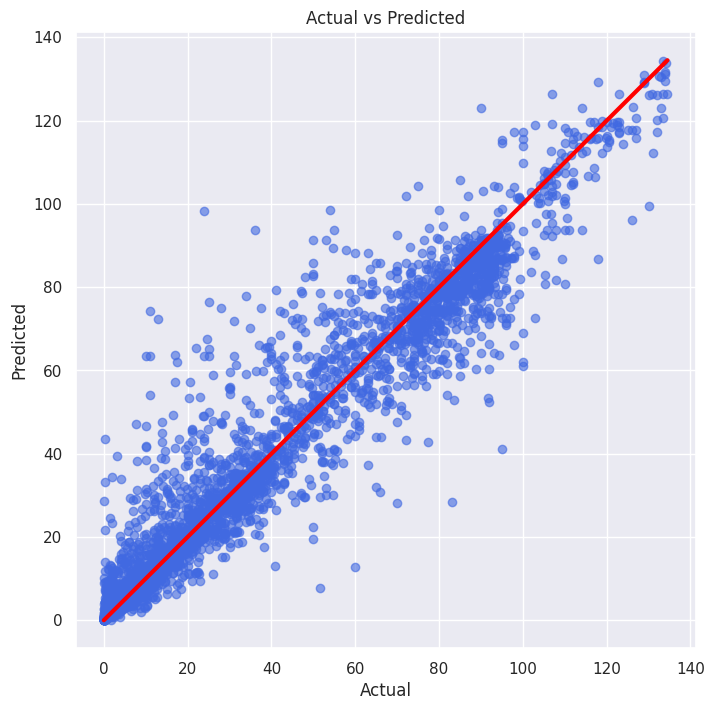

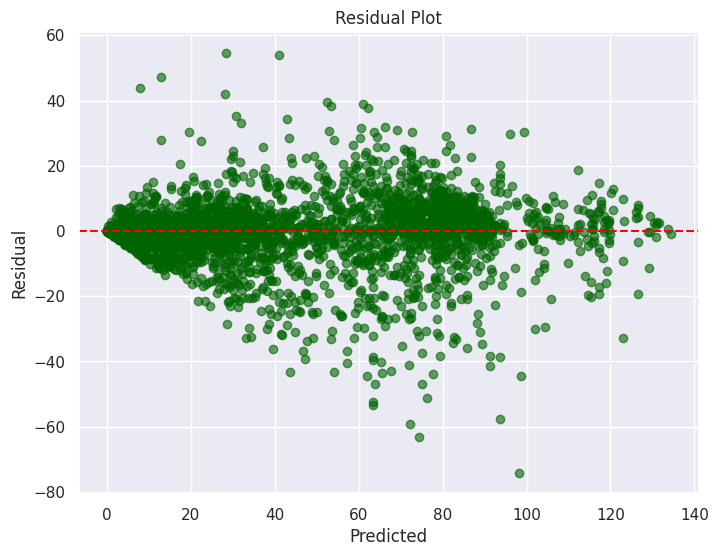

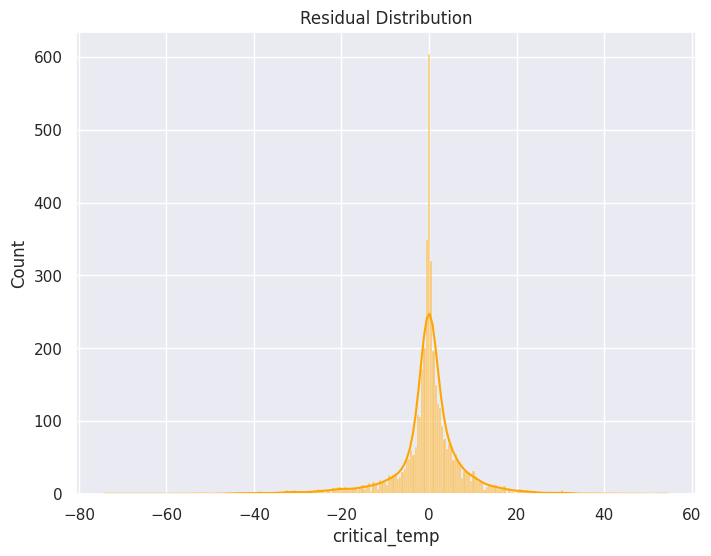


Top Important Features

                            Feature  Importance
67        range_ThermalConductivity    0.193067
70      wtd_std_ThermalConductivity    0.165808
69          std_ThermalConductivity    0.065778
27              range_atomic_radius    0.050537
72                 wtd_mean_Valence    0.031245
6           wtd_entropy_atomic_mass    0.028704
76              wtd_entropy_Valence    0.026421
74                wtd_gmean_Valence    0.021667
17                        range_fie    0.020861
44       wtd_gmean_ElectronAffinity    0.019987
26        wtd_entropy_atomic_radius    0.018789
62     wtd_mean_ThermalConductivity    0.017544
9                   std_atomic_mass    0.017305
50         wtd_std_ElectronAffinity    0.013787
7                 range_atomic_mass    0.013610
80                  wtd_std_Valence    0.012576
66  wtd_entropy_ThermalConductivity    0.010831
43           gmean_ElectronAffinity    0.010829
48       wtd_range_ElectronAffinity    0.009840
78             

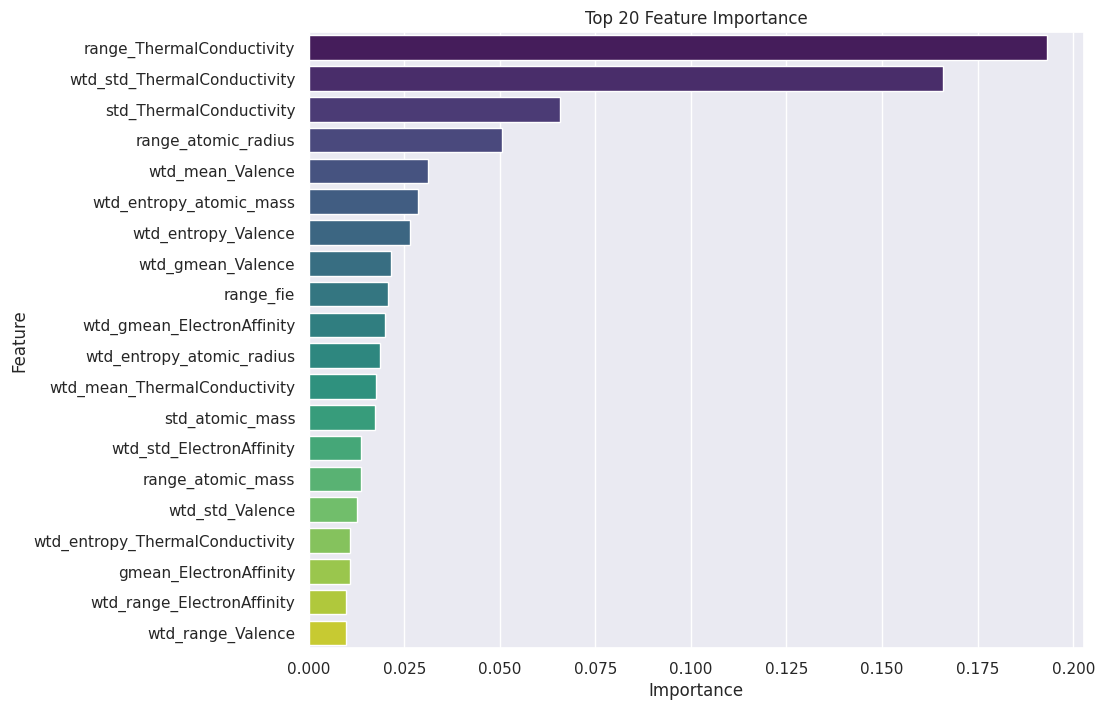

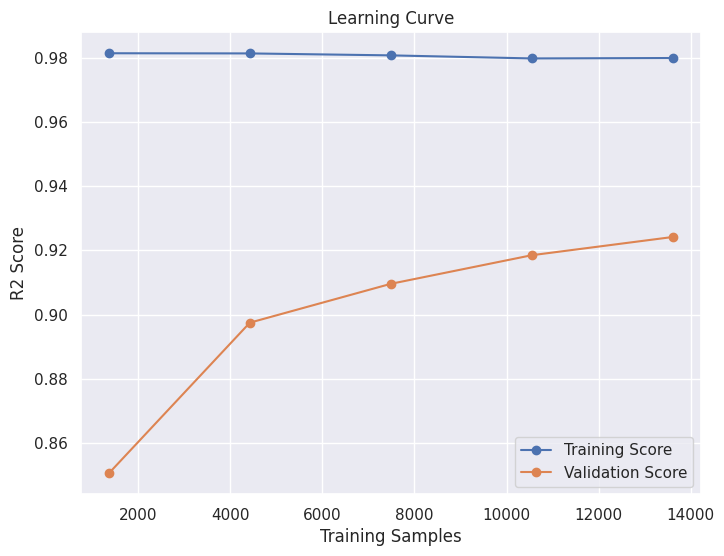


Model Saved Successfully
Model Loaded Successfully

Predictions
[11.4574893  84.53046581 27.30196402 17.46655077 10.26729015]
    Actual   Predicted
0    6.400   11.457489
1   91.200   84.530466
2   38.000   27.301964
3   19.000   17.466551
4   11.000   10.267290
5   62.000   67.079271
6   84.000   86.994114
7   50.100   59.097880
8   35.000   29.854220
9    8.020   12.072424
10   7.214    6.838433
11  37.500   31.420043
12  33.500   43.545753
13  33.000   18.792618
14   5.000    6.002305
15  40.000   39.013753
16  21.800   11.457489
17  80.000   74.471875
18  77.000   76.591706
19  90.100   90.832978
20   4.650    4.827260
21   8.111    9.808325
22  18.900   20.016986
23   2.350    3.957908
24  14.300   16.561771
25  43.000   33.302168
26  29.200   28.947314
27  92.000   81.698304
28   4.330    3.956677
29  18.400   18.687140
30   6.500    6.760027
31  10.100   10.134510
32   1.170    3.908489
33  92.100   85.052001
34  82.000   75.127897
35   2.910    3.173362
36  24.100   21.717281

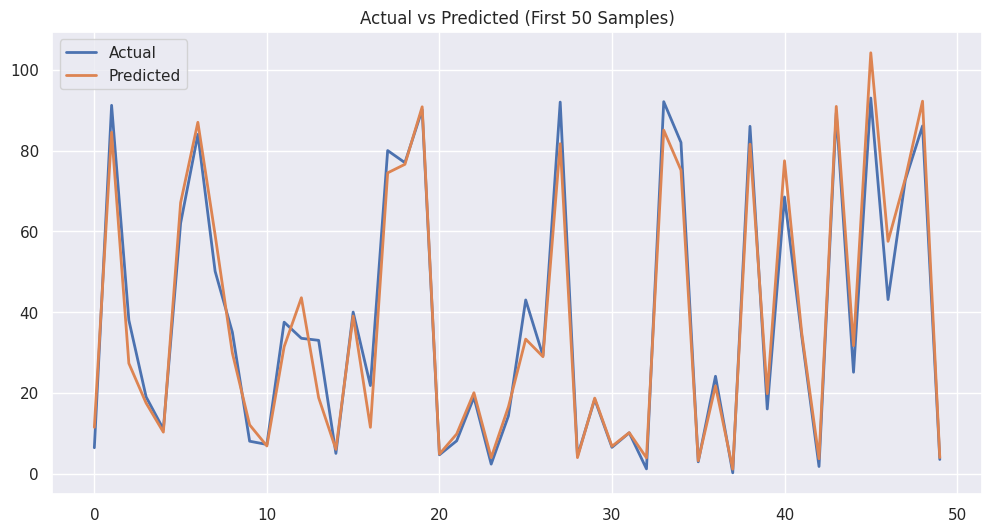


Pipeline Completed Successfully.


In [28]:
# ============================================================
# SUPERCONDUCTOR DATASET - REGRESSION PIPELINE (PART 2)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import RandomizedSearchCV, learning_curve

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

print("="*60)
print("BEST MODEL :", best_model_name)
print("="*60)

model = best_model.named_steps["model"]

param_grid = {}

if best_model_name == "Random Forest":

    param_grid = {
        "model__n_estimators":[100,200,300,500],
        "model__max_depth":[None,10,20,30],
        "model__min_samples_split":[2,5,10],
        "model__min_samples_leaf":[1,2,4]
    }

elif best_model_name == "Extra Trees":

    param_grid = {
        "model__n_estimators":[100,200,300],
        "model__max_depth":[None,10,20],
        "model__min_samples_split":[2,5],
        "model__min_samples_leaf":[1,2]
    }

elif best_model_name == "Gradient Boosting":

    param_grid = {
        "model__n_estimators":[100,200,300],
        "model__learning_rate":[0.01,0.05,0.1],
        "model__max_depth":[3,5,7]
    }

elif best_model_name == "XGBoost":

    param_grid = {
        "model__n_estimators":[100,200,300],
        "model__learning_rate":[0.01,0.05,0.1],
        "model__max_depth":[3,5,7]
    }

elif best_model_name == "LightGBM":

    param_grid = {
        "model__n_estimators":[100,200,300],
        "model__learning_rate":[0.01,0.05,0.1],
        "model__num_leaves":[31,50,70]
    }

elif best_model_name == "CatBoost":

    param_grid = {
        "model__iterations":[200,300],
        "model__depth":[4,6,8],
        "model__learning_rate":[0.01,0.05,0.1]
    }

if len(param_grid) > 0:

    search = RandomizedSearchCV(

        estimator=best_model,

        param_distributions=param_grid,

        n_iter=10,

        cv=5,

        random_state=42,

        scoring="r2",

        n_jobs=-1

    )

    search.fit(X_train,y_train)

    best_model = search.best_estimator_

    print("\nBest Parameters\n")

    print(search.best_params_)

else:

    print("Hyperparameter tuning skipped for this model.")

# ============================================================
# PREDICTION
# ============================================================

prediction = best_model.predict(X_test)

r2 = r2_score(y_test,prediction)

mae = mean_absolute_error(y_test,prediction)

mse = mean_squared_error(y_test,prediction)

rmse = np.sqrt(mse)

print("\n==========================")

print("FINAL PERFORMANCE")

print("==========================")

print("R2 :",round(r2,4))

print("MAE :",round(mae,4))

print("MSE :",round(mse,4))

print("RMSE :",round(rmse,4))

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    prediction,
    color="royalblue",
    alpha=0.6
)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red",

    linewidth=3

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(

    prediction,

    residuals,

    color="darkgreen",

    alpha=0.6

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# ============================================================
# ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,6))

sns.histplot(

    residuals,

    kde=True,

    color="orange"

)

plt.title("Residual Distribution")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

model = best_model.named_steps["model"]

feature_names = numerical_columns.copy()

if len(categorical_columns) > 0:

    ohe = best_model.named_steps["preprocessor"]\
                    .named_transformers_["cat"]\
                    .named_steps["encoder"]

    cat_names = ohe.get_feature_names_out(categorical_columns)

    feature_names.extend(cat_names)

if hasattr(model,"feature_importances_"):

    importance = pd.DataFrame({

        "Feature":feature_names,

        "Importance":model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    print("\nTop Important Features\n")

    print(importance.head(20))

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance.head(20),

        x="Importance",

        y="Feature",

        palette="viridis"

    )

    plt.title("Top 20 Feature Importance")

    plt.show()

else:

    print("\nFeature Importance not available.")

# ============================================================
# LEARNING CURVE
# ============================================================

train_sizes,train_scores,test_scores = learning_curve(

    best_model,

    X_train,

    y_train,

    cv=5,

    scoring="r2",

    train_sizes=np.linspace(0.1,1.0,5),

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(

    train_sizes,

    train_mean,

    marker="o",

    label="Training Score"

)

plt.plot(

    train_sizes,

    test_mean,

    marker="o",

    label="Validation Score"

)

plt.xlabel("Training Samples")

plt.ylabel("R2 Score")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

joblib.dump(

    best_model,

    "best_superconductor_model.pkl"

)

print("\nModel Saved Successfully")

# ============================================================
# LOAD MODEL
# ============================================================

loaded_model = joblib.load(

    "best_superconductor_model.pkl"

)

print("Model Loaded Successfully")

# ============================================================
# PREDICT NEW DATA
# ============================================================

sample = X_test.iloc[:5]

prediction = loaded_model.predict(sample)

print("\nPredictions")

print(prediction)

# ============================================================
# COMPLETE RESULT TABLE
# ============================================================

comparison = pd.DataFrame({

    "Actual":y_test.iloc[:50].values,

    "Predicted":prediction[:50] if len(prediction)>=50 else loaded_model.predict(X_test.iloc[:50])

})

print(comparison)

plt.figure(figsize=(12,6))

plt.plot(

    comparison["Actual"].values,

    label="Actual",

    linewidth=2

)

plt.plot(

    comparison["Predicted"].values,

    label="Predicted",

    linewidth=2

)

plt.title("Actual vs Predicted (First 50 Samples)")

plt.legend()

plt.grid(True)

plt.show()

print("\nPipeline Completed Successfully.")